# Week 11 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']


In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y


## Function 1

In [3]:
# Cell A — F1 setup + data overview (post W10 determinism test)
N = 1
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.6g}  |  Y range [{Y.min():.4g}, {Y.max():.4g}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

# W10 was an exact repeat of the W3 best — detect duplicates and build a deduped view
_, uidx = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(uidx)], Y[np.sort(uidx)]
n_dup = len(X) - len(Xd)
print(f"\nDuplicate points: {n_dup} (W10 repeated W3 best exactly; Y returned bit-for-bit identical -> F1 is DETERMINISTIC)")
print(f"Deduped: {len(Xd)} unique points ({(Yd>=0).sum()} positive / {(Yd<0).sum()} negative)")

print("\nAll points sorted by Y (★ = last week's query):")
for i in np.argsort(Y)[::-1]:
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  ({X[i,0]:.6f}, {X[i,1]:.6f})  Y={Y[i]:+.4e}{star}")


Function 1: 20 points, 2D, best y = 0.0000
Baseline=0.00160764  |  Y range [-0.006627, 3.651e-07]
Per-dim correlations: r(x1,Y)=+0.092, r(x2,Y)=+0.011

Duplicate points: 1 (W10 repeated W3 best exactly; Y returned bit-for-bit identical -> F1 is DETERMINISTIC)
Deduped: 19 unique points (13 positive / 6 negative)

All points sorted by Y (★ = last week's query):
  (0.700201, 0.695377)  Y=+3.6511e-07 ★W10
  (0.700201, 0.695377)  Y=+3.6511e-07
  (0.710746, 0.699736)  Y=+1.1462e-08
  (0.724297, 0.702040)  Y=+1.1333e-10
  (0.731024, 0.733000)  Y=+7.7109e-16
  (0.665351, 0.437391)  Y=+1.8940e-28
  (0.780000, 0.780000)  Y=+2.5001e-32
  (0.683418, 0.861057)  Y=+2.5350e-40
  (0.228696, 0.565819)  Y=+6.2443e-42
  (0.574329, 0.879898)  Y=+1.0331e-46
  (0.883890, 0.582254)  Y=+6.2299e-48
  (0.319404, 0.762959)  Y=+1.3227e-79
  (0.082507, 0.403488)  Y=+3.6068e-81
  (0.840353, 0.264732)  Y=+3.3418e-124
  (0.312691, 0.078723)  Y=-2.0891e-91
  (0.617191, 0.222274)  Y=-1.8090e-57
  (0.410437, 0.147554)  

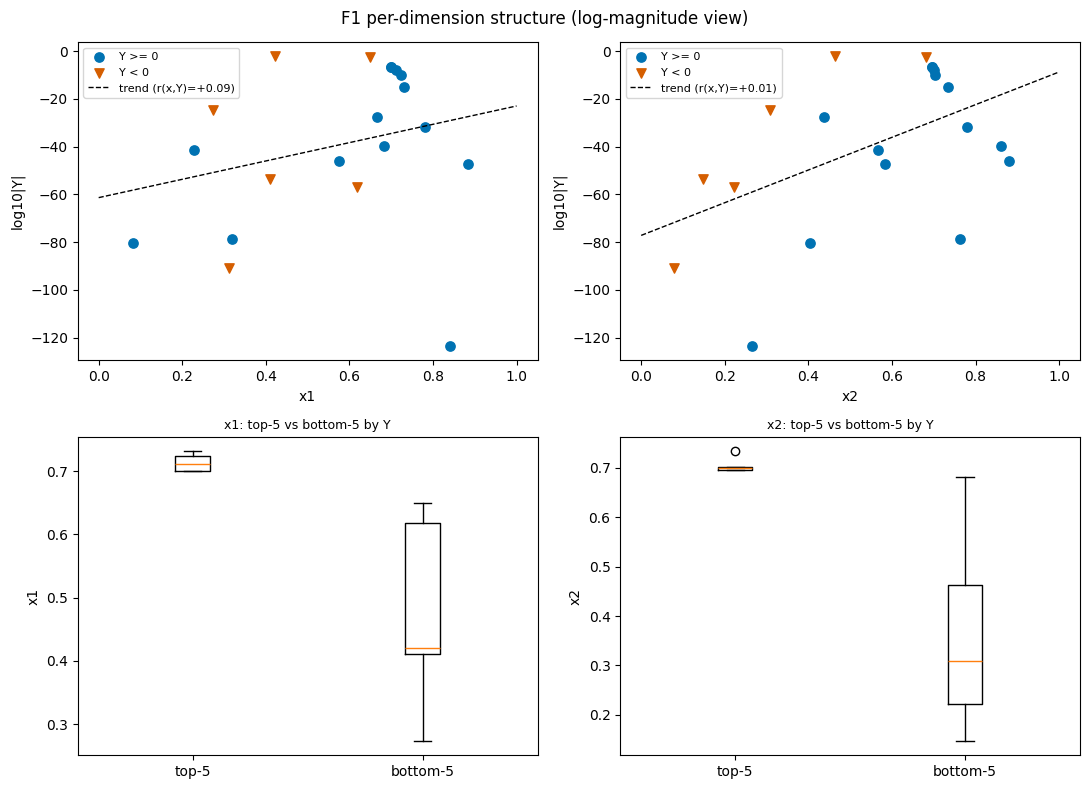

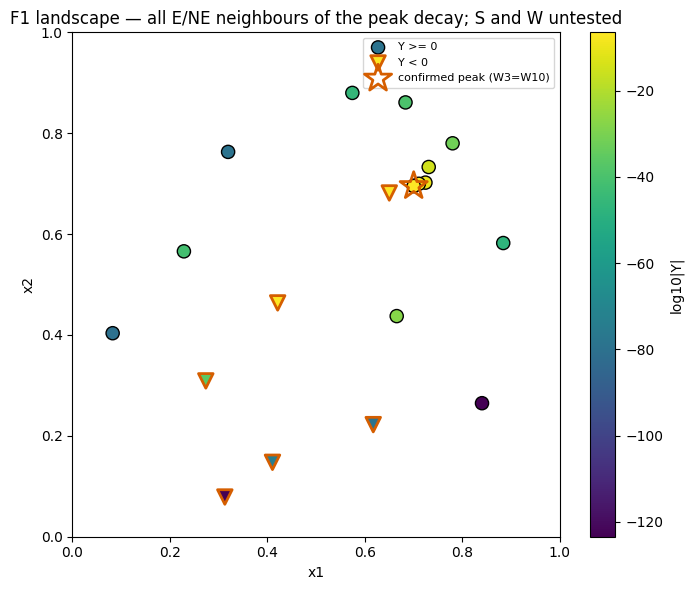

In [4]:
# Cell B — F1 per-dim scatter + top/bottom boxplots + 2D sign-aware map
# Y spans ~120 orders of magnitude, so row 1 plots log10|Y| coloured by sign
logmag = np.log10(np.abs(Y) + 1e-200)
sign_pos = Y >= 0
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    ax.scatter(X[sign_pos, d], logmag[sign_pos], c='#0072B2', label='Y >= 0', s=45)
    ax.scatter(X[~sign_pos, d], logmag[~sign_pos], c='#D55E00', marker='v', label='Y < 0', s=45)
    z = np.polyfit(X[:, d], logmag, 1)
    xs = np.linspace(0, 1, 50)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'trend (r(x,Y)={r:+.2f})')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('log10|Y|'); ax.legend(fontsize=8)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axb = axes[1, d]
    axb.boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axb.set_ylabel(f'x{d+1}'); axb.set_title(f'x{d+1}: top-5 vs bottom-5 by Y', fontsize=9)
plt.suptitle('F1 per-dimension structure (log-magnitude view)')
plt.tight_layout(); plt.savefig('../plots/week_11/function_1_per_dim.png', dpi=110); plt.show()

# 2D landscape: position coloured by log10|Y|, marker = sign
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X[sign_pos, 0], X[sign_pos, 1], c=logmag[sign_pos], cmap='viridis', s=90, marker='o', edgecolor='k', label='Y >= 0')
ax.scatter(X[~sign_pos, 0], X[~sign_pos, 1], c=logmag[~sign_pos], cmap='viridis', s=110, marker='v', edgecolor='#D55E00', linewidths=2, label='Y < 0')
peak = X[Y.argmax()]
ax.scatter(*peak, marker='*', s=420, facecolor='none', edgecolor='#D55E00', linewidths=2, label='confirmed peak (W3=W10)')
plt.colorbar(sc, label='log10|Y|')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title('F1 landscape — all E/NE neighbours of the peak decay; S and W untested')
plt.tight_layout(); plt.savefig('../plots/week_11/function_1_2d_scatter.png', dpi=110); plt.show()


In [5]:
# Cell C — F1 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")
print("\nNote: raw-Y importances are near-meaningless for F1 (two -1e-3 points dominate the variance).")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.552    0.623        0.794   0.092
x2    0.448    0.377        0.206   0.011

Note: raw-Y importances are near-meaningless for F1 (two -1e-3 points dominate the variance).


In [6]:
# Cell D — F1 model grid search (incl. NN) vs baseline
from sklearn.model_selection import cross_val_predict
import nn_models as nm

def loo_rmse(est, X, Y):
    p = cross_val_predict(est, X, Y, cv=LeaveOneOut())
    return np.sqrt(np.mean((p - Y) ** 2))

results = {}
gs = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['Ridge'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['KNN'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['RF'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['SVR'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.3]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['GB'] = np.sqrt(-gs.best_score_)
for nu in [0.5, 1.5, 2.5]:
    results[f'GP-Matern{nu}'] = loo_rmse(GaussianProcessRegressor(Matern(nu=nu), normalize_y=True, alpha=1e-10), X, Y)
results['GP-RBF'] = loo_rmse(GaussianProcessRegressor(RBF(), normalize_y=True, alpha=1e-10), X, Y)
nn_model_1, nn_meta_1 = nm.load_nn(1, models_dir='../models/week_11')
results['NN'] = nn_meta_1['cv_rmse']

beats_models = {}
print(f"baseline (Y.std) = {baseline:.6f}\n")
print(f"{'model':14s} {'LOO RMSE':>10s}  vs baseline")
for k, v in results.items():
    beat = v < baseline
    if beat:
        beats_models[k] = v
    print(f"{k:14s} {v:>10.6f}  {'✓' if beat else '✗'} ({(baseline - v) / baseline * 100:+.1f}%)")
print(f"\n{len(beats_models)} models beat baseline -> Cell E {'runs' if beats_models else 'SKIPPED (expected for F1 — raw-Y regression is hopeless)'}")


baseline (Y.std) = 0.001608

model            LOO RMSE  vs baseline
Ridge            0.001693  ✗ (-5.3%)
KNN              0.001769  ✗ (-10.1%)
RF               0.001935  ✗ (-20.4%)
SVR              0.003324  ✗ (-106.8%)
GB               0.001810  ✗ (-12.6%)
GP-Matern0.5     0.001684  ✗ (-4.7%)
GP-Matern1.5     0.001684  ✗ (-4.7%)
GP-Matern2.5     0.001684  ✗ (-4.7%)
GP-RBF           0.001684  ✗ (-4.7%)
NN               0.002583  ✗ (-60.7%)

0 models beat baseline -> Cell E SKIPPED (expected for F1 — raw-Y regression is hopeless)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

SVC C=  1: LOO acc = 84.21% deduped  (85.00% with duplicate — inflated)
SVC C= 10: LOO acc = 84.21% deduped  (85.00% with duplicate — inflated)
SVC C=100: LOO acc = 73.68% deduped  (75.00% with duplicate — inflated)
LogReg : LOO acc = 68.42% deduped
KNN-3  : LOO acc = 73.68% deduped

Chosen SVC C=1, LOO=84.21% -> still below the 85% trust gate
log-SVR {'C': 100, 'gamma': 'scale'}: LOO RMSE=18.32 vs std=32.59 (+43.8%)
Calibration at confirmed peak: predicted log10|Y|=-6.54 vs actual -6.44



Global combined candidate (0.6803, 0.6466): P(+)=0.835, pred log10|Y|=-1.54
Trust checks: clf>=85%? False | far from negatives (>0.85)? False (d=0.046) | within observed positive magnitudes? False
-> combined candidate NOT trusted (fails classifier gate + sits next to the largest negatives = the extrapolation trap)
-> Cell F2 below: the deep structural analysis this rejection motivated, which produces this week's query


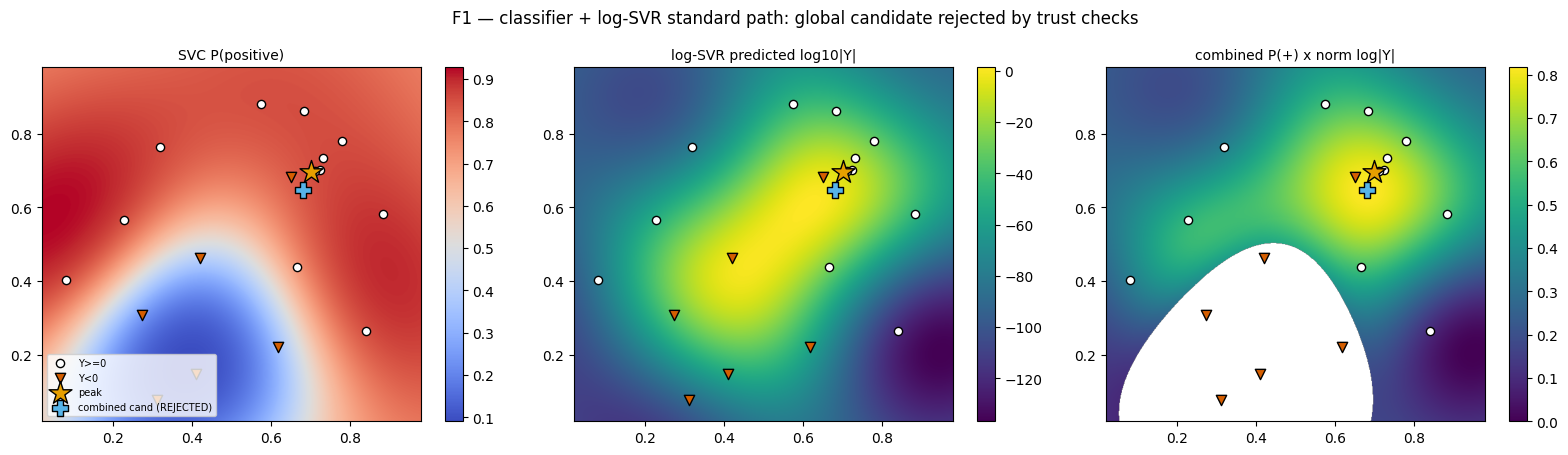

In [7]:
# Cell F — F1 classifier + log-SVR combined (standard primary path, see f1_long_term_strategy.md)
# All fits on DEDUPED data: the W10 duplicate inflates LOO accuracy (its twin is always in training)
sign_d = (Yd >= 0).astype(int)
Lmag = np.log10(np.abs(Yd) + 1e-200)

# 1) SVC sign classifier, LOO accuracy — report deduped (honest) AND with-duplicate (inflated)
accs = {}
for C in [1, 10, 100]:
    accs[C] = cross_val_score(SVC(C=C, kernel='rbf'), Xd, sign_d, cv=LeaveOneOut()).mean()
    acc_dup = cross_val_score(SVC(C=C, kernel='rbf'), X, (Y >= 0).astype(int), cv=LeaveOneOut()).mean()
    print(f"SVC C={C:>3}: LOO acc = {accs[C]*100:.2f}% deduped  ({acc_dup*100:.2f}% with duplicate — inflated)")
for name, clf in [('LogReg', LogisticRegression()), ('KNN-3', KNeighborsClassifier(3))]:
    print(f"{name:7s}: LOO acc = {cross_val_score(clf, Xd, sign_d, cv=LeaveOneOut()).mean()*100:.2f}% deduped")
best_C = max(accs, key=accs.get)
clf_acc = accs[best_C]
svc = SVC(C=best_C, kernel='rbf', probability=True, random_state=0).fit(Xd, sign_d)
print(f"\nChosen SVC C={best_C}, LOO={clf_acc*100:.2f}% -> {'≥85% gate PASSED' if clf_acc >= 0.85 else 'still below the 85% trust gate'}")

# 2) log-SVR on log10|Y| (magnitude field)
gs = GridSearchCV(SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(Xd, Lmag)
logsvr = gs.best_estimator_.fit(Xd, Lmag)
print(f"log-SVR {gs.best_params_}: LOO RMSE={np.sqrt(-gs.best_score_):.2f} vs std={Lmag.std():.2f} ({(Lmag.std()-np.sqrt(-gs.best_score_))/Lmag.std()*100:+.1f}%)")
peak = X[Y.argmax()]
print(f"Calibration at confirmed peak: predicted log10|Y|={logsvr.predict(peak[None])[0]:.2f} vs actual {np.log10(Y.max()):.2f}")

# 3) combined score on dense grid + trust checks for the global candidate
g = 600
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
P = svc.predict_proba(cand)[:, 1]
Lp = logsvr.predict(cand)
Ln = (Lp - Lp.min()) / (Lp.max() - Lp.min())
comb = np.where(P > 0.5, P * Ln, -np.inf)
gb = comb.argmax()
negs = Xd[Yd < 0]
d_gb_neg = cdist(cand[gb][None], negs).min()
avg_pd = cdist(Xd, Xd)[np.triu_indices(len(Xd), 1)].mean()
print(f"\nGlobal combined candidate ({cand[gb,0]:.4f}, {cand[gb,1]:.4f}): P(+)={P[gb]:.3f}, pred log10|Y|={Lp[gb]:.2f}")
print(f"Trust checks: clf>=85%? {clf_acc >= 0.85} | far from negatives (>{2*avg_pd:.2f})? {d_gb_neg > 2*avg_pd} (d={d_gb_neg:.3f})"
      f" | within observed positive magnitudes? {Lp[gb] <= np.log10(Y.max())}")
print("-> combined candidate NOT trusted (fails classifier gate + sits next to the largest negatives = the extrapolation trap)")
print("-> Cell F2 below: the deep structural analysis this rejection motivated, which produces this week's query")

# 4) 3-panel plot: P(+), magnitude field, combined score (rejected candidate shown)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, Z, title, cm in [(axes[0], P, 'SVC P(positive)', 'coolwarm'),
                         (axes[1], Lp, 'log-SVR predicted log10|Y|', 'viridis'),
                         (axes[2], np.where(np.isfinite(comb), comb, np.nan), 'combined P(+) x norm log|Y|', 'viridis')]:
    im = ax.imshow(Z.reshape(g, g), origin='lower', extent=[0.02, 0.98, 0.02, 0.98], cmap=cm, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.scatter(Xd[Yd >= 0, 0], Xd[Yd >= 0, 1], c='white', edgecolor='k', s=35, label='Y>=0')
    ax.scatter(negs[:, 0], negs[:, 1], c='#D55E00', marker='v', edgecolor='k', s=55, label='Y<0')
    ax.scatter(*peak, marker='*', s=300, c='#E69F00', edgecolor='k', label='peak')
    ax.scatter(*cand[gb], marker='P', s=140, c='#56B4E9', edgecolor='k', label='combined cand (REJECTED)')
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=7, loc='lower left')
plt.suptitle('F1 — classifier + log-SVR standard path: global candidate rejected by trust checks')
plt.tight_layout(); plt.savefig('../plots/week_11/function_1_combined.png', dpi=110); plt.show()


Quadratic fit of ln|Y| (19 unique pts, 6 params): R^2 = 0.9732
Hessian eigenvalues [-3578. -1283.] -> concave (a true Gaussian ridge), long axis ~ diagonal x1=x2
Gaussian center: (0.5369, 0.5374) — NEVER sampled; nearest points are its shoulders

LOO RMSE of the quadratic: 19.9 ln units (vs ln|Y| std 75.0)
ln|Y| at center across all 19 LOO refits: 13.3 ± 2.6  [min 8.8, max 22.6]
-> EVERY refit predicts |Y(center)| ≥ 6.4e+03 — observed max |Y| is only 0.0066
-> the summit of the magnitude ridge is unsampled; both -1e-3 negatives sit 0.14–0.18 off-center on its shoulders

SVC P(positive) at center = 0.633 (clf honest LOO 84.2%) — leans positive, ~60/40 bet
dist center -> nearest negative 0.137, -> nearest positive 0.163
Attempts to identify the sign-carrier h parametrically (plane-wave / grid / radial-chirp cosines,
poly deg2-3 via variable projection) all fit signs WORSE than the SVC (<=79% vs 84%) -> sign stays empirical.

pred ln|Y| at confirmed peak:   -19.7  (actual -14.8)
pred ln|Y

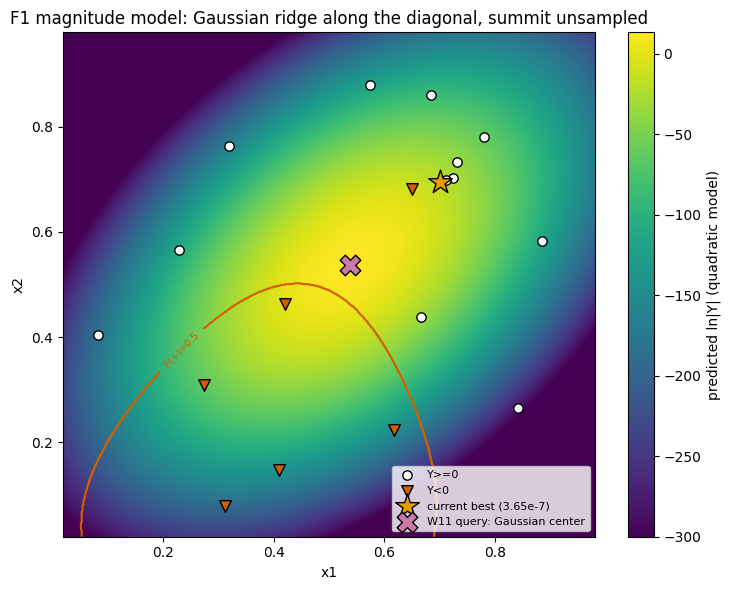

In [8]:
# Cell F2 — F1 DEEP STRUCTURAL ANALYSIS: ln|Y| is a concave quadratic -> Gaussian magnitude model
# Motivation: |Y| spans ~120 orders of magnitude. If f(x) = h(x)*exp(quadratic) with an oscillatory
# sign-carrier h, then ln|Y| should fit a quadratic surface almost exactly. It does.
Lnat = np.log(np.abs(Yd))
def qfeats(P):
    return np.column_stack([np.ones(len(P)), P[:, 0], P[:, 1], P[:, 0]**2, P[:, 1]**2, P[:, 0]*P[:, 1]])
AQ = qfeats(Xd)
qcoef, *_ = np.linalg.lstsq(AQ, Lnat, rcond=None)
pred = AQ @ qcoef
r2 = 1 - ((Lnat - pred)**2).sum() / ((Lnat - Lnat.mean())**2).sum()
Hq = np.array([[2*qcoef[3], qcoef[5]], [qcoef[5], 2*qcoef[4]]])
evals, evecs = np.linalg.eigh(Hq)
gauss_center = np.linalg.solve(-Hq, qcoef[1:3])
print(f"Quadratic fit of ln|Y| (19 unique pts, 6 params): R^2 = {r2:.4f}")
print(f"Hessian eigenvalues {np.round(evals,0)} -> concave (a true Gaussian ridge), long axis ~ diagonal x1=x2")
print(f"Gaussian center: ({gauss_center[0]:.4f}, {gauss_center[1]:.4f}) — NEVER sampled; nearest points are its shoulders")

# Honest uncertainty: predict the center under every leave-one-out refit
center_preds, loo_err = [], []
for i in range(len(Xd)):
    m = np.ones(len(Xd), bool); m[i] = False
    c_i, *_ = np.linalg.lstsq(AQ[m], Lnat[m], rcond=None)
    loo_err.append(Lnat[i] - AQ[i] @ c_i)
    center_preds.append(qfeats(gauss_center[None])[0] @ c_i)
center_preds, loo_err = np.array(center_preds), np.array(loo_err)
print(f"\nLOO RMSE of the quadratic: {np.sqrt((loo_err**2).mean()):.1f} ln units (vs ln|Y| std {Lnat.std():.1f})")
print(f"ln|Y| at center across all 19 LOO refits: {center_preds.mean():.1f} ± {center_preds.std():.1f}  [min {center_preds.min():.1f}, max {center_preds.max():.1f}]")
print(f"-> EVERY refit predicts |Y(center)| ≥ {np.exp(center_preds.min()):.2g} — observed max |Y| is only {np.abs(Yd).max():.2g}")
print(f"-> the summit of the magnitude ridge is unsampled; both -1e-3 negatives sit 0.14–0.18 off-center on its shoulders")

# Sign evidence at the center (sign is the only open question)
p_center = svc.predict_proba(gauss_center[None])[0, 1]
print(f"\nSVC P(positive) at center = {p_center:.3f} (clf honest LOO {clf_acc*100:.1f}%) — leans positive, ~60/40 bet")
print(f"dist center -> nearest negative {cdist(gauss_center[None], negs).min():.3f}, -> nearest positive {cdist(gauss_center[None], Xd[Yd >= 0]).min():.3f}")
print("Attempts to identify the sign-carrier h parametrically (plane-wave / grid / radial-chirp cosines,")
print("poly deg2-3 via variable projection) all fit signs WORSE than the SVC (<=79% vs 84%) -> sign stays empirical.")

# Compare strategies under the magnitude model
print(f"\npred ln|Y| at confirmed peak: {qfeats(peak[None])[0] @ qcoef:7.1f}  (actual {np.log(Y.max()):.1f})")
print(f"pred ln|Y| at Gaussian center: {qfeats(gauss_center[None])[0] @ qcoef:7.1f}")
print("-> any |Δ|~0.03 refinement near the peak moves ~3 ln units; the center is ~33 ln units up the same ridge.")

# W11 query: argmax of predicted ln|Y| subject to P(positive) >= 0.5 (uses Cell F grid)
lnmag_grid = qfeats(cand) @ qcoef
m_pos = P >= 0.5
b = np.where(m_pos, lnmag_grid, -np.inf).argmax()
center_query = cand[b].copy()
b70 = np.where(P >= 0.7, lnmag_grid, -np.inf).argmax()
print(f"\nargmax pred|Y| s.t. P(+)>=0.5: ({center_query[0]:.6f}, {center_query[1]:.6f})  pred ln|Y|={lnmag_grid[b]:.1f}  P(+)={P[b]:.3f}")
print(f"(safer P>=0.7 alternative: ({cand[b70,0]:.4f}, {cand[b70,1]:.4f}) pred ln|Y|={lnmag_grid[b70]:.1f} — same bet within classifier noise; not used)")

# Plot: magnitude model + signs + chosen query
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(np.clip(lnmag_grid, -300, 20).reshape(g, g), origin='lower', extent=[0.02, 0.98, 0.02, 0.98], cmap='viridis', aspect='auto')
plt.colorbar(im, label='predicted ln|Y| (quadratic model)')
cs = ax.contour(gx, gy, P.reshape(g, g), levels=[0.5], colors='#D55E00', linewidths=1.5)
ax.clabel(cs, fmt='P(+)=0.5', fontsize=7)
ax.scatter(Xd[Yd >= 0, 0], Xd[Yd >= 0, 1], c='white', edgecolor='k', s=45, label='Y>=0')
ax.scatter(negs[:, 0], negs[:, 1], c='#D55E00', marker='v', edgecolor='k', s=70, label='Y<0')
ax.scatter(*peak, marker='*', s=320, c='#E69F00', edgecolor='k', label='current best (3.65e-7)')
ax.scatter(*center_query, marker='X', s=220, c='#CC79A7', edgecolor='k', label='W11 query: Gaussian center')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(fontsize=8, loc='lower right')
ax.set_title('F1 magnitude model: Gaussian ridge along the diagonal, summit unsampled')
plt.tight_layout(); plt.savefig('../plots/week_11/function_1_magnitude_model.png', dpi=110); plt.show()


### F1 — Decision

**Query: `next_query_1 = center_query` → the Gaussian-magnitude-model center, ≈(0.538, 0.538) (computed in Cell F2, printed in Cell I).**

Method: structural model — `f(x) = h(x) · exp(quadratic)` — magnitude argmax subject to P(positive) ≥ 0.5.

Why: W10's exact repeat proved F1 is deterministic and the W3 peak real — but the deep analysis shows that peak is a **molehill on the shoulder of an unsampled mountain**. ln|Y| fits a concave quadratic with R² = 0.97 (a Gaussian ridge along the diagonal, center ≈ (0.537, 0.537)). Every one of the 19 leave-one-out refits predicts |Y| at the center ≥ ~6e3, i.e. ≥10⁶× the largest |Y| ever observed and ~10¹⁰× the current best positive (3.65e-7). The two large negatives (-6.6e-3, -3.6e-3) are the ridge's shoulders, 0.14–0.18 from the summit. We have spent 6 weeks refining 30 ln-units below the top of the ridge.

The only open question is **sign** at the center: h(x) oscillates (the +1.9e-28 point at (0.665, 0.437) sits ~30 ln-units below the magnitude fit — essentially ON a zero of h) and no parametric form for h beat the SVC (84.21% honest deduped LOO; the with-duplicate 85.0% is inflated). The SVC leans positive at the center: P(+) = 0.63. This is a ~60/40 bet with an extreme payoff asymmetry:

- **Win**: Y plausibly ≥ 1e-3 — thousands to millions of times the current best.
- **Lose**: one week (six have already gone to failed 30×-down refinements), and we still get the two most valuable observations possible — the first sample of the ridge summit (calibrates the magnitude model's amplitude) and the most informative sign point on the board, setting up a positive-lobe shot in W12.

For comparison, the standard-path candidates were rejected on their own terms: the global combined candidate fails the classifier gate and sits 0.05 from the largest negative (extrapolation trap), and a cautious trust-region step S of the peak predicts only ~8e-8 under the global magnitude model — it wouldn't even beat the current best.

Branch (Step 5):
- [x] 1. No models beat baseline (0/10 on raw Y — expected) → F1 special case, escalated: classifier + structural magnitude model (Cell F2) instead of the untrusted combined path

Per-dimension justification:
- x1 ≈ 0.538 — Gaussian center (model-derived, not a data centroid; nearest samples flank it on both sides)
- x2 ≈ 0.538 — same; the ridge's long axis runs along x1 ≈ x2, and the center is its maximum

W12 contingency:
- If Y > 0 (any magnitude): jackpot or calibration — if large, exploit with small steps along the ridge axis; if small-positive, h has a zero near the center → step along the ridge to the adjacent positive lobe using the refitted model.
- If Y < 0: summit is in a negative lobe of h. Refit the quadratic with the new point (it will pin the amplitude), refit the SVC, and query the magnitude argmax constrained to the positive side — the adjacent lobe along the ridge axis. The negative's magnitude itself tells us how high the mountain is.
- Either way: re-check the honest deduped classifier LOO; with this high-information point it may finally cross 85%.


In [9]:
# Cell I — next_query_1 assignment
next_query_1 = center_query.copy()
print(f"F1 query: " + ", ".join(f"{v:.6f}" for v in next_query_1))


F1 query: 0.537663, 0.537663


## Function 2

In [10]:
# Cell A — F2 setup + DETERMINISM INVESTIGATION
N = 2
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

# F1/F4 exact repeats (W10) were bit-for-bit identical -> deterministic.
# F2 has its own exact repeat: W6 and W9 BOTH queried (0.703636, 0.946935). Check at full precision:
dup_mask = np.all(np.isclose(X, [0.703636, 0.946935], atol=1e-9), axis=1)
print(f"\nExact duplicate input (0.703636, 0.946935) queried {dup_mask.sum()}x -> Y = {Y[dup_mask]}")
print(f"  -> SAME input, DIFFERENT output (Δ={abs(np.diff(Y[dup_mask])[0]):.4f}). F2 is STOCHASTIC — the exception among the 8.")

# Second, independent near-repeat: W10 (0.665800, 0.123969) vs init (0.6657996, 0.1239691) — Δx ~ 4e-7
near = np.all(np.isclose(X, [0.6658, 0.123969], atol=1e-5), axis=1)
print(f"\nNear-repeat at secondary region (Δx ≈ 4e-7): Y = {Y[near]}")
print(f"  -> Δ={abs(np.diff(Y[near])[0]):.4f}. No smooth function moves 0.10 over 4e-7. Confirms noise.")

diffs = np.array([np.diff(Y[dup_mask])[0], np.diff(Y[near])[0]])
sigma_noise = float(np.sqrt(np.mean(diffs**2) / 2))
print(f"\nNoise sigma from the 2 repeat pairs: {sigma_noise:.4f}")

labels = ['init']*10 + [f'W{w}' for w in range(1, 11)]
print("\nAll points sorted by Y (★ = W10):")
for i in np.argsort(Y)[::-1]:
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  [{labels[i]:>4}] ({X[i,0]:.6f}, {X[i,1]:.6f})  Y={Y[i]:+.4f}{star}")


Function 2: 20 points, 2D, best y = 0.6961
Baseline=0.2365  |  Y range [-0.0656, 0.6961]
Per-dim correlations: r(x1,Y)=+0.586, r(x2,Y)=+0.625

Exact duplicate input (0.703636, 0.946935) queried 2x -> Y = [0.69611942 0.62508778]
  -> SAME input, DIFFERENT output (Δ=0.0710). F2 is STOCHASTIC — the exception among the 8.

Near-repeat at secondary region (Δx ≈ 4e-7): Y = [0.53899612 0.43619723]
  -> Δ=0.1028. No smooth function moves 0.10 over 4e-7. Confirms noise.

Noise sigma from the 2 repeat pairs: 0.0625

All points sorted by Y (★ = W10):
  [  W6] (0.703636, 0.946935)  Y=+0.6961
  [  W3] (0.701898, 0.953338)  Y=+0.6658
  [  W9] (0.703636, 0.946935)  Y=+0.6251
  [init] (0.702637, 0.926564)  Y=+0.6112
  [  W7] (0.703084, 0.943835)  Y=+0.5756
  [init] (0.665800, 0.123969)  Y=+0.5390
  [  W5] (0.693851, 0.962584)  Y=+0.4995
  [  W8] (0.708074, 0.946424)  Y=+0.4588
  [ W10] (0.665800, 0.123969)  Y=+0.4362 ★W10
  [  W2] (0.750000, 0.920000)  Y=+0.4265
  [init] (0.877791, 0.778628)  Y=+0.420

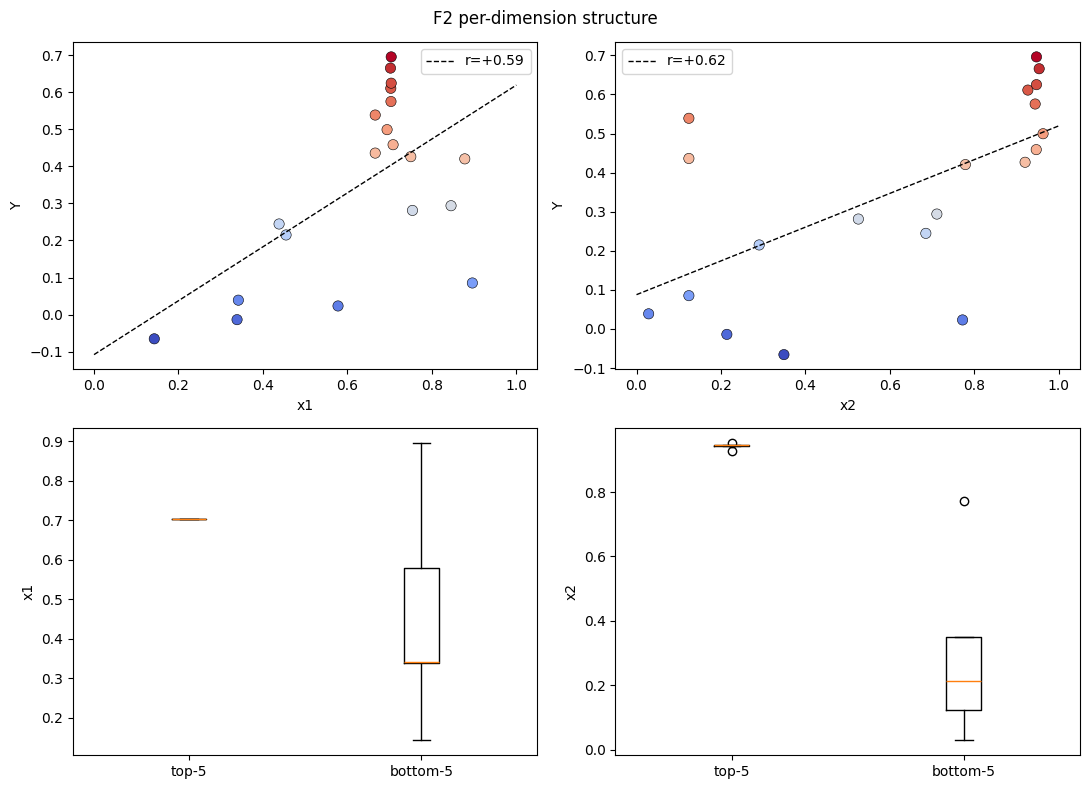

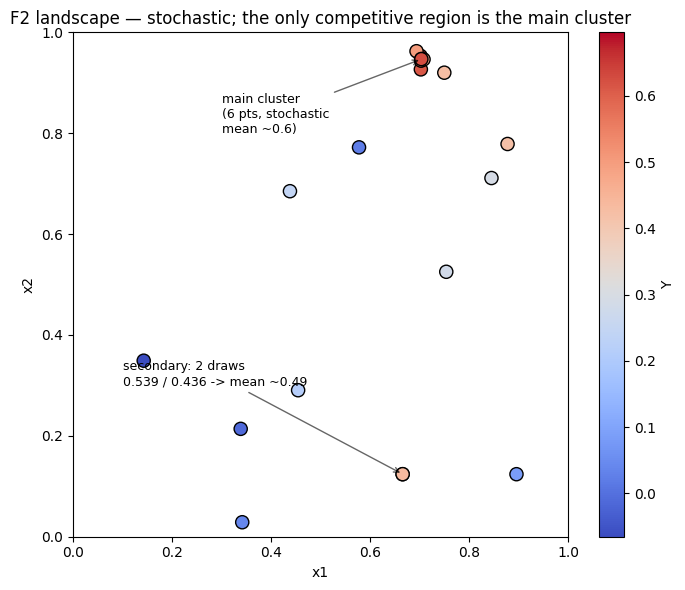

In [11]:
# Cell B — F2 per-dim scatter + boxplots + 2D map
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    sc = ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=55, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F2 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_2_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=90, edgecolor='k')
plt.colorbar(sc, label='Y')
ax.annotate('main cluster\n(6 pts, stochastic\nmean ~0.6)', (0.704, 0.947), xytext=(0.30, 0.80),
            arrowprops=dict(arrowstyle='->', alpha=0.6), fontsize=9)
ax.annotate('secondary: 2 draws\n0.539 / 0.436 -> mean ~0.49', (0.666, 0.124), xytext=(0.10, 0.30),
            arrowprops=dict(arrowstyle='->', alpha=0.6), fontsize=9)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('F2 landscape — stochastic; the only competitive region is the main cluster')
plt.tight_layout(); plt.savefig('../plots/week_11/function_2_2d_scatter.png', dpi=110); plt.show()


In [12]:
# Cell C — F2 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.555    0.582        0.606   0.586
x2    0.445    0.418        0.394   0.625


In [13]:
# Cell D — F2 model grid (noise-aware GPs: WhiteKernel REQUIRED — duplicate X with different Y
# makes alpha=1e-10 GPs numerically singular and conceptually wrong now that F2 is proven stochastic)
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, k in [('GP-Matern05+W', ConstantKernel()*Matern(0.3,nu=0.5)+WhiteKernel(0.003)),
               ('GP-Matern15+W', ConstantKernel()*Matern(0.3,nu=1.5)+WhiteKernel(0.003)),
               ('GP-Matern25+W', ConstantKernel()*Matern(0.3,nu=2.5)+WhiteKernel(0.003)),
               ('GP-RBF+W', ConstantKernel()*RBF(0.3)+WhiteKernel(0.003))]:
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>14} {'LOO RMSE':>9}  vs baseline={baseline:.4f} (noise floor sigma={sigma_noise:.3f})")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>13} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")
gp_best = beats_models['GP-Matern05+W'][0]
print(f"\nGP-Matern05+W learned kernel: {gp_best.kernel_}")
print(f"  -> learned noise variance {gp_best.kernel_.k2.noise_level:.3f} (normalized-Y); independently confirms the repeat-pair noise estimate")
print(f"\n{len(beats_models)}/10 beat baseline")


         Model  LOO RMSE  vs baseline=0.2365 (noise floor sigma=0.062)
          Ridge    0.1586  ✓ (+32.9%)
            KNN    0.1160  ✓ (+51.0%)
             RF    0.1239  ✓ (+47.6%)
            SVR    0.1399  ✓ (+40.8%)
             GB    0.1121  ✓ (+52.6%)
  GP-Matern05+W    0.1306  ✓ (+44.8%)
  GP-Matern15+W    0.1401  ✓ (+40.7%)
  GP-Matern25+W    0.1457  ✓ (+38.4%)
       GP-RBF+W    0.1541  ✓ (+34.8%)
             NN    0.1804  ✓ (+23.7%)

GP-Matern05+W learned kernel: 0.985**2 * Matern(length_scale=0.276, nu=0.5) + WhiteKernel(noise_level=0.106)
  -> learned noise variance 0.106 (normalized-Y); independently confirms the repeat-pair noise estimate

10/10 beat baseline


In [14]:
# Cell E — F2 model suggestions + STRATEGY INVESTIGATION (stochastic objective)
# F2 is stochastic, and the graded metric is the best SINGLE draw. The banked best is 0.6961.
# So the right acquisition is NOT just argmax(mean): it is argmax P(one noisy draw > 0.6961).
from scipy.stats import norm

rng = np.random.default_rng(0); cand_r = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  {'x1':>7} {'x2':>7}  {'pred Y':>8}  bound?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand_r); i = int(yhat.argmax()); pt = cand_r[i]
    bnd = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = (pt, float(yhat[i]), bnd)
    print(f"  {name:>13}  {pt[0]:>7.4f} {pt[1]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if bnd else ''}")
valid = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v[2]}
sug = np.array([v[0] for v in valid.values()])
print(f"\nValid interior (non-Ridge): {list(valid.keys())}")
print(f"Per-dim spread: x1={sug[:,0].max()-sug[:,0].min():.3f}, x2={sug[:,1].max()-sug[:,1].min():.3f}")

# Strategy comparison on a dense grid with the noise-aware GP
best_banked = float(Y.max())
g = 400
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
mu, sd = gp_best.predict(cand, return_std=True)        # sd = latent (epistemic) std
sd_obs = np.sqrt(sd**2 + sigma_noise**2)                 # one observation also carries noise
pi = 1 - norm.cdf((best_banked - mu) / sd_obs)           # P(single draw beats banked best)
i_mean, i_ucb, i_pi = mu.argmax(), (mu + sd).argmax(), pi.argmax()
print(f"\nAcquisition comparison (banked best {best_banked:.4f}):")
for name, i in [('argmax posterior mean', i_mean), ('argmax UCB beta=1', i_ucb), ('argmax P(beat banked)', i_pi)]:
    print(f"  {name:>22}: ({cand[i,0]:.4f}, {cand[i,1]:.4f})  mu={mu[i]:.4f}  P(beat)={pi[i]:.3f}")
print(f"\nReference P(beat): secondary region={pi[np.argmin(cdist(cand, [[0.6658, 0.124]]))]:.3f}, "
      f"unexplored mid={pi[np.argmin(cdist(cand, [[0.45, 0.85]]))]:.3f}")
print("-> All three acquisitions CONVERGE on the same cluster-interior point; nothing else is within 9x. Exploit.")
pbeat_query = cand[i_pi].copy()


         Model       x1      x2    pred Y  bound?
          Ridge   0.9997  0.9946    0.6322  ⚠
            KNN   0.7019  0.9534    0.6657  


             RF   0.7046  0.9535    0.6561  
            SVR   0.7412  0.9998    0.6249  ⚠
             GB   0.7016  0.9530    0.6591  
  GP-Matern05+W   0.7036  0.9471    0.5990  
  GP-Matern15+W   0.6967  0.9543    0.5816  
  GP-Matern25+W   0.6862  0.9728    0.5868  
       GP-RBF+W   0.6776  0.9997    0.6026  ⚠


             NN   0.7471  0.9999    0.6375  ⚠

Valid interior (non-Ridge): ['KNN', 'RF', 'GB', 'GP-Matern05+W', 'GP-Matern15+W', 'GP-Matern25+W']
Per-dim spread: x1=0.018, x2=0.026

Acquisition comparison (banked best 0.6961):
   argmax posterior mean: (0.7009, 0.9487)  mu=0.5971  P(beat)=0.180
       argmax UCB beta=1: (0.7009, 0.9487)  mu=0.5971  P(beat)=0.180
   argmax P(beat banked): (0.7009, 0.9487)  mu=0.5971  P(beat)=0.180

Reference P(beat): secondary region=0.021, unexplored mid=0.015
-> All three acquisitions CONVERGE on the same cluster-interior point; nothing else is within 9x. Exploit.


### F2 — Decision

**Query: `next_query_2 = pbeat_query` → ≈(0.701, 0.949) — argmax P(one draw > banked 0.6961) under the noise-aware GP.**

Method: noise-aware GP (Matern05 + WhiteKernel) posterior, acquisition = probability that a single noisy draw beats the banked best.

**The key W11 finding — F2 is stochastic, the exception among the 8.** Two independent repeat pairs prove it: the W6/W9 exact duplicate (0.703636, 0.946935) returned 0.6961 vs 0.6251, and the W10 near-repeat of the secondary init point (Δx ≈ 4e-7) returned 0.436 vs 0.539. No smooth deterministic function does either. Noise σ ≈ 0.06, and the GP's learned WhiteKernel independently confirms it. F1/F4's W10 bit-for-bit repeats make the contrast sharp: those are deterministic, F2 is not.

**Strategy investigation (asked this week): is the current strategy still right?** With a stochastic function and the graded metric being the best single draw, the correct objective is P(draw > 0.6961), not argmax of the mean. I compared three acquisitions on the noise-aware posterior — argmax mean, UCB (β=1), and argmax P(beat) — and all three converge on the same cluster-interior point (0.701, 0.949), P(beat) ≈ 0.18. The secondary region (P ≈ 0.02) and unexplored space (P ≈ 0.015) are 9–12× worse bets. Conclusion: the main cluster IS the answer; the W10 secondary test closed the only open alternative. Each remaining week is an independent ~18% lottery ticket at the cluster's sweet spot — that is the best available play, and both remaining weeks should likely spend F2's query on it.

Branch (Step 5):
- [x] 5-adjacent (strong models, converged suggestions) escalated to a stochastic-objective acquisition — models agree, and the acquisition convergence makes the choice unambiguous.

Per-dimension justification:
- x1 ≈ 0.701 — noise-aware GP posterior, within the 6-point cluster
- x2 ≈ 0.949 — same; flanked by W3 (0.9533) and W6/W9 (0.9469) draws

W12 contingency:
- Y > 0.6961: new banked best (lucky draw above the ~0.60 mean). Repeat the same acquisition — refit GP, query its new argmax-P(beat).
- Y ∈ [0.45, 0.70]: consistent with mean ~0.6, σ 0.06. Same plan in W12 — another ticket.
- Y < 0.40: would be a 3+σ draw OR evidence the local mean is lower than fit; refit and re-check, but with only one week left, still take the cluster ticket.


In [15]:
# Cell I — next_query_2 assignment
next_query_2 = pbeat_query.copy()
print(f"F2 query: " + ", ".join(f"{v:.6f}" for v in next_query_2))
print(f"  Method: noise-aware GP, argmax P(single draw > banked best {Y.max():.4f})")


F2 query: 0.700902, 0.948722
  Method: noise-aware GP, argmax P(single draw > banked best 0.6961)


## Function 3

In [16]:
# Cell A — F3 setup + outlier check + structural ln(-Y) test
N = 3
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*15 + [f'W{w}' for w in range(1, 11)]
print("\nTop 10 by Y (★ = W10):")
for rank, i in enumerate(np.argsort(Y)[::-1][:10]):
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  {rank+1:>2}. [{labels[i]:>4}] ({X[i,0]:.4f}, {X[i,1]:.4f}, {X[i,2]:.4f})  Y={Y[i]:+.4f}{star}")

# Standard F3 outlier-correlation check (the W8 lesson)
i_worst = int(Y.argmin())
print(f"\nOutlier-correlation check (worst point Y={Y[i_worst]:.4f} at x3={X[i_worst,2]:.3f}):")
for d in range(3):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = '  ⚠ inflated by outlier' if abs(r_no - r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_without_worst={r_no:+.3f}{flag}")

# STRATEGY INVESTIGATION 1: F1-style structural model? All Y < 0 and approaching 0 -> try ln(-Y) quadratic
Z = np.log(-Y)
def qfeats3(P):
    return np.column_stack([np.ones(len(P)), P, P**2, P[:,[0]]*P[:,[1]], P[:,[0]]*P[:,[2]], P[:,[1]]*P[:,[2]]])
A3 = qfeats3(X)
qc, *_ = np.linalg.lstsq(A3, Z, rcond=None)
r2 = 1 - ((Z - A3@qc)**2).sum() / ((Z - Z.mean())**2).sum()
loo_e = []
for i in range(len(X)):
    m = np.ones(len(X), bool); m[i] = False
    ci, *_ = np.linalg.lstsq(A3[m], Z[m], rcond=None)
    loo_e.append(Z[i] - A3[i] @ ci)
Hq = np.array([[2*qc[4], qc[7], qc[8]], [qc[7], 2*qc[5], qc[9]], [qc[8], qc[9], 2*qc[6]]])
ev = np.linalg.eigvalsh(Hq)
print(f"\nStructural test — quadratic fit of ln(-Y): R²={r2:.3f}, LOO RMSE={np.sqrt(np.mean(np.array(loo_e)**2)):.3f} vs std={Z.std():.3f}")
print(f"Hessian eigenvalues {np.round(ev,1)} -> {'convex' if all(ev>0) else 'SADDLE'}")
print("-> REJECTED: unlike F1 (R²=0.97), F3 has no global exponential-pit structure. LOO worse than baseline std.")


Function 3: 25 points, 3D, best y = -0.0264
Baseline=0.0724  |  Y range [-0.3989, -0.0264]
Per-dim correlations: r(x1,Y)=+0.307, r(x2,Y)=+0.181, r(x3,Y)=-0.590

Top 10 by Y (★ = W10):
   1. [ W10] (0.6428, 0.6089, 0.0702)  Y=-0.0264 ★W10
   2. [  W8] (0.6583, 0.6162, 0.0729)  Y=-0.0274
   3. [init] (0.4926, 0.6116, 0.3402)  Y=-0.0348
   4. [init] (0.6001, 0.7251, 0.0661)  Y=-0.0364
   5. [  W2] (0.4811, 0.5326, 0.0518)  Y=-0.0400
   6. [  W9] (0.6681, 0.6800, 0.0899)  Y=-0.0418
   7. [  W4] (0.3679, 0.4565, 0.3375)  Y=-0.0469
   8. [init] (0.2205, 0.2978, 0.3436)  Y=-0.0469
   9. [  W5] (0.5145, 0.5469, 0.3401)  Y=-0.0470
  10. [init] (0.1346, 0.2199, 0.4582)  Y=-0.0480

Outlier-correlation check (worst point Y=-0.3989 at x3=0.991):
  x1: r_all=+0.307, r_without_worst=+0.131
  x2: r_all=+0.181, r_without_worst=+0.159
  x3: r_all=-0.590, r_without_worst=-0.258  ⚠ inflated by outlier

Structural test — quadratic fit of ln(-Y): R²=0.527, LOO RMSE=0.730 vs std=0.624
Hessian eigenvalues [-4

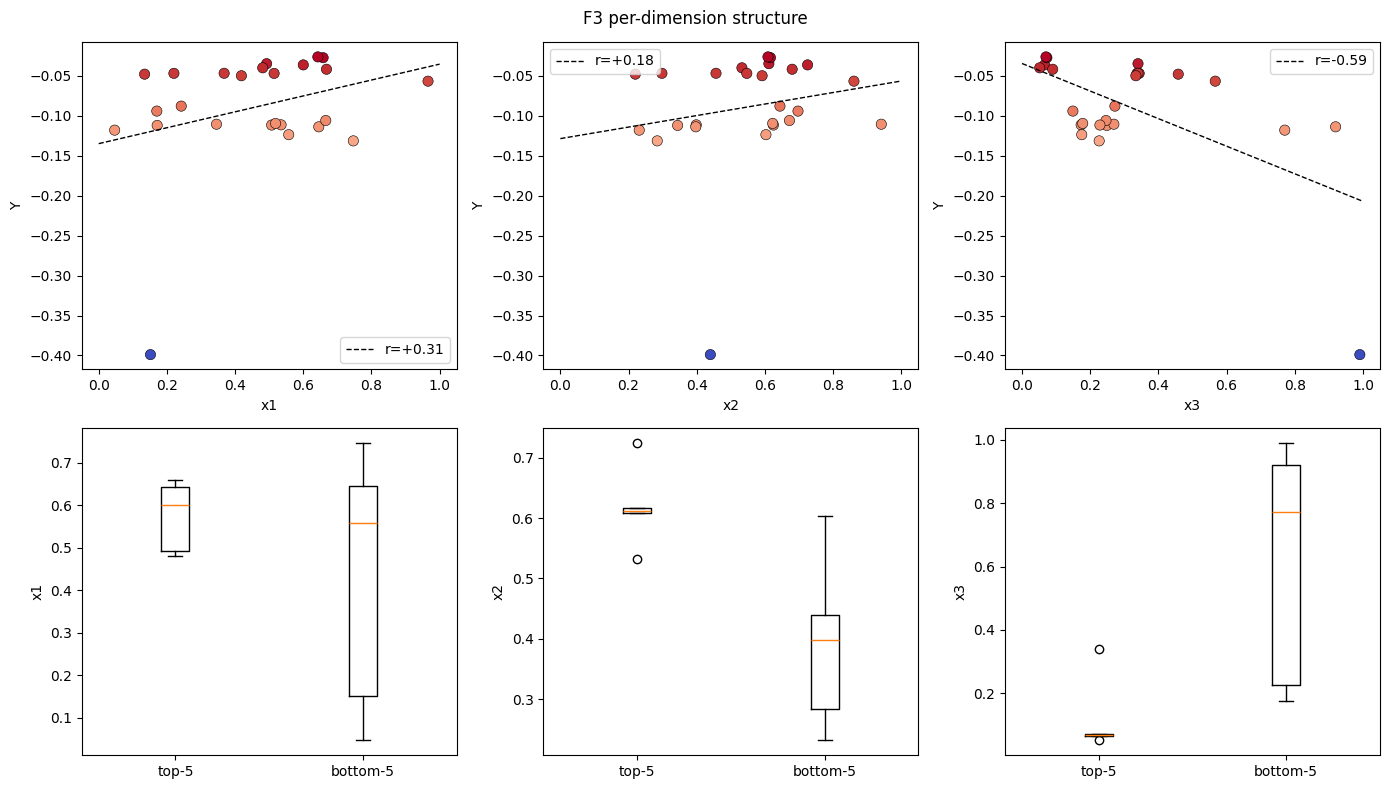

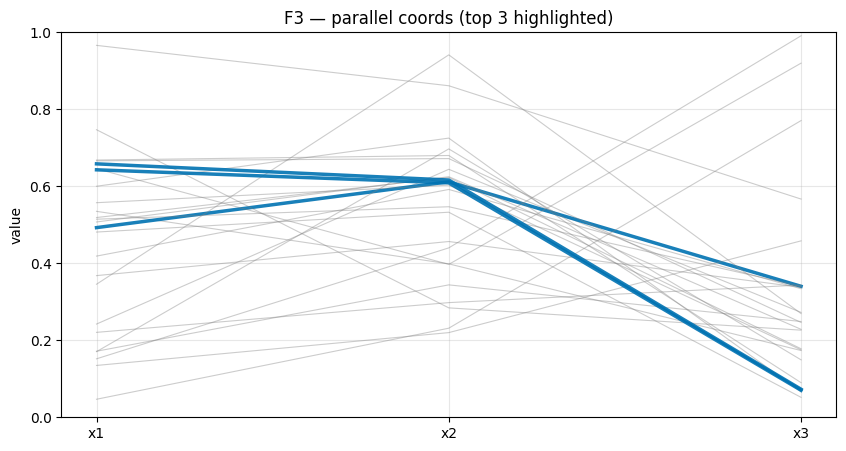

In [17]:
# Cell B — F3 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for d in range(3):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=55, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F3 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_3_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(3), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(3), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(3)); ax.set_xticklabels(['x1', 'x2', 'x3'])
ax.set(ylim=(0,1), ylabel='value', title='F3 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_3_parallel.png', dpi=110); plt.show()


In [18]:
# Cell C — F3 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.077    0.093        0.229   0.307
x2    0.053    0.059        0.164   0.181
x3    0.870    0.848        0.607   0.590


In [19]:
# Cell D — F3 model grid (incl. Warped + NN)
from output_warping import WarpedRegressor
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
from sklearn.gaussian_process.kernels import ConstantKernel
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
wr = WarpedRegressor(RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0))
score = -cross_val_score(wr, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
results.append(('Warped-RF', score, wr.fit(X, Y)))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>13} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>12} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")
print(f"\n{len(beats_models)}/12 beat baseline")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


        Model  LOO RMSE  vs baseline=0.0724
         Ridge    0.0466  ✓ (+35.7%)
           KNN    0.0343  ✓ (+52.6%)
            RF    0.0301  ✓ (+58.4%)
           SVR    0.0692  ✓ (+4.4%)
            GB    0.0297  ✓ (+59.0%)
   GP-Matern05    0.0398  ✓ (+44.9%)
   GP-Matern15    0.0323  ✓ (+55.3%)
   GP-Matern25    0.0292  ✓ (+59.6%)
        GP-RBF    0.0317  ✓ (+56.2%)
     Warped-RF    0.0273  ✓ (+62.3%)
            NN    0.0695  ✓ (+3.9%)

11/12 beat baseline


In [20]:
# Cell E — F3 suggestions + STRATEGY INVESTIGATION (bimodal x3 -> EI comparison)
from scipy.stats import norm
rng = np.random.default_rng(0); cand_r = rng.uniform(size=(200_000, 3))
print(f"{'Model':>13}  {'x1':>7} {'x2':>7} {'x3':>7}  {'pred Y':>9}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yh = est.predict(cand_r); i = int(yh.argmax()); pt = cand_r[i]
    bnd = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = (pt, float(yh[i]), bnd)
    print(f"  {name:>12}  {pt[0]:>7.4f} {pt[1]:>7.4f} {pt[2]:>7.4f}  {yh[i]:>9.4f}  {'⚠' if bnd else ''}")
valid = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v[2]}
sug = np.array([v[0] for v in valid.values()])
print(f"\nValid interior: {list(valid.keys())}")
for d in range(3):
    spread = sug[:,d].max() - sug[:,d].min()
    label = 'STRONG' if spread < 0.2 else ('moderate' if spread < 0.4 else 'weak')
    print(f"  x{d+1}: spread={spread:.3f} [{label}]")
print("\n-> x1/x2 STRONG; x3 BIMODAL: trees say cluster B (~0.07), the two best-CV GPs say ~0.48 with POSITIVE pred Y.")
print("   The naive RMSE-weighted ensemble would average x3 to ~0.19 — the valley where W3 failed (-0.11). Ensemble = trap this week.")

# EI comparison: cluster-B refinement vs the unexplored x3-ridge (vs banked best)
best_banked = float(Y.max())
gp25 = beats_models['GP-Matern25'][0]; gprbf = beats_models['GP-RBF'][0]
def ei(gp, c):
    m, s = gp.predict(c, return_std=True)
    z = (m - best_banked) / np.maximum(s, 1e-12)
    return (m - best_banked) * norm.cdf(z) + s * norm.pdf(z)
cand_e = np.random.default_rng(1).uniform(0.02, 0.98, size=(300_000, 3))
ei_avg = (ei(gp25, cand_e) + ei(gprbf, cand_e)) / 2
i_ei = int(ei_avg.argmax())
ridge_query = cand_e[i_ei].copy()
hyb = np.array([[0.62, 0.615, 0.068]])
ei_hyb = float(((ei(gp25, hyb) + ei(gprbf, hyb)) / 2)[0])
print(f"\nEI vs banked best ({best_banked:.4f}):")
print(f"  x3-ridge argmax EI: ({ridge_query[0]:.4f}, {ridge_query[1]:.4f}, {ridge_query[2]:.4f})  EI={ei_avg[i_ei]:.4f}")
print(f"  cluster-B hybrid:   (0.62, 0.615, 0.068)  EI={ei_hyb:.5f}")
print(f"  -> ridge EI is {ei_avg[i_ei]/max(ei_hyb,1e-9):.0f}x higher. Cluster-B refinement predicts -0.026±0.003 = ZERO expected gain.")
print(f"\nDownside check (trees at the ridge point): "
      f"GB={beats_models['GB'][0].predict(ridge_query[None])[0]:+.4f}, "
      f"RF={beats_models['RF'][0].predict(ridge_query[None])[0]:+.4f}, "
      f"KNN={beats_models['KNN'][0].predict(ridge_query[None])[0]:+.4f} (mid-table, not catastrophic)")


        Model       x1      x2      x3     pred Y  bnd?
         Ridge   0.9988  0.9671  0.0036    -0.0750  ⚠
           KNN   0.6583  0.6162  0.0729    -0.0274  


            RF   0.6299  0.6184  0.0780    -0.0316  
           SVR   0.9670  0.7762  0.0006    -0.1213  ⚠


            GB   0.5863  0.6112  0.0711    -0.0348  
   GP-Matern05   0.6501  0.6330  0.0262    -0.0234  
   GP-Matern15   0.6489  0.6332  0.0019     0.0103  ⚠
   GP-Matern25   0.5264  0.6025  0.4740     0.0223  
        GP-RBF   0.5485  0.6212  0.4869     0.0667  


     Warped-RF   0.6299  0.6184  0.0780    -0.0296  
            NN   0.0018  0.0042  0.4629     0.0575  ⚠

Valid interior: ['KNN', 'RF', 'GB', 'GP-Matern05', 'GP-Matern25', 'GP-RBF', 'Warped-RF']
  x1: spread=0.132 [STRONG]
  x2: spread=0.030 [STRONG]
  x3: spread=0.461 [weak]

-> x1/x2 STRONG; x3 BIMODAL: trees say cluster B (~0.07), the two best-CV GPs say ~0.48 with POSITIVE pred Y.
   The naive RMSE-weighted ensemble would average x3 to ~0.19 — the valley where W3 failed (-0.11). Ensemble = trap this week.

EI vs banked best (-0.0264):
  x3-ridge argmax EI: (0.5353, 0.6069, 0.4888)  EI=0.0725
  cluster-B hybrid:   (0.62, 0.615, 0.068)  EI=0.00164
  -> ridge EI is 44x higher. Cluster-B refinement predicts -0.026±0.003 = ZERO expected gain.

Downside check (trees at the ridge point): GB=-0.0502, RF=-0.0535, KNN=-0.0434 (mid-table, not catastrophic)


### F3 — Decision

**Query: `next_query_3 = ridge_query` → ≈(0.535, 0.607, 0.489) — argmax Expected Improvement on the unexplored x3-ridge.**

Method: GP Expected Improvement (average of the two best-CV models, GP-Matern25 +60% and GP-RBF +56%) against the banked best -0.0264.

**Strategy investigation (asked this week): is cluster-B ensemble refinement still the best?** Three findings say no:
1. **The F1-style structural test fails for F3** (ln(-Y) quadratic: R² 0.53, LOO worse than baseline, saddle Hessian) — no exponential-pit shortcut. Investigated and rejected.
2. **Cluster-B refinement has saturated.** W8→W10 gained +0.001; the GPs predict -0.026 ± 0.003 at the next refinement step — statistically indistinguishable from the banked best. Expected gain ≈ 0.
3. **The model suggestions are bimodal on x3** — trees at the known cluster B (x3≈0.07), the two best-CV GPs at x3≈0.48-0.49 with predicted positive Y. The naive RMSE-weighted ensemble averages the modes to x3≈0.19, exactly the valley where W3 landed -0.11. This week the standard ensemble is a trap, and the right comparison is EI: the unexplored ridge at (0.54, 0.61, 0.49) has **44× the EI** of another cluster-B step.

The bet is bounded: the x3∈[0.40, 0.60] band with good x1/x2 has never been sampled (the two existing x3≈0.5 points have terrible x1/x2 and still ranked mid-table at -0.048/-0.057). Tree models predict ≈-0.04 to -0.05 at the ridge point (a mid-table miss, costing essentially nothing vs a zero-gain refinement). The GPs lean positive (+0.02 to +0.07) — which would be the first positive Y in 26 observations. W12 remains for the safe cluster-B step if this misses.

Branch (Step 5):
- [x] 5-adjacent escalation: strong models, but bimodal disagreement on x3 → EI arbitration instead of the (degenerate) per-dim hybrid

Per-dimension justification:
- x1 ≈ 0.535 — EI argmax; within the STRONG x1 consensus band (0.53-0.66)
- x2 ≈ 0.607 — EI argmax; matches the STRONG x2 consensus (~0.61)
- x3 ≈ 0.489 — the unexplored ridge the two best CV models point to; NOT the naive ensemble average

W12 contingency:
- Y > -0.0264 (new best / first positive): ridge is real. Refit GPs, take their new EI argmax — likely a local refinement of the ridge.
- Y ∈ [-0.05, -0.0264]: mid-table, ridge plausible but summit elsewhere. Refit; W12 chooses between refined-ridge EI and cluster-B fine step by the same EI comparison.
- Y < -0.05: ridge rejected, GPs were extrapolation-fooled. W12 = cluster-B fine refinement (0.62, 0.615, 0.068) — the safe close-out.


In [21]:
# Cell I — next_query_3 assignment
next_query_3 = ridge_query.copy()
print(f"F3 query: " + ", ".join(f"{v:.6f}" for v in next_query_3))
print(f"  Method: GP-EI arbitration of bimodal x3 (unexplored ridge bet; 44x EI vs cluster-B refinement)")


F3 query: 0.535311, 0.606855, 0.488771
  Method: GP-EI arbitration of bimodal x3 (unexplored ridge bet; 44x EI vs cluster-B refinement)


## Function 4

In [22]:
# Cell A — F4 setup + determinism + cliff anatomy
N = 4
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

# Dedupe the W6/W10 twin (W10 noise-test returned bit-for-bit identical Y -> F4 deterministic)
_, uidx = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(uidx)], Y[np.sort(uidx)]
print(f"\nDuplicates: {len(X)-len(Xd)} (W10 = exact W6 repeat, Y identical -> DETERMINISTIC; deduped for all fits)")

labels = ['init']*30 + [f'W{w}' for w in range(1, 11)]
best = X[Y.argmax()]
print("\nTop 9 by Y (★ = W10):")
for rank, i in enumerate(np.argsort(Y)[::-1][:9]):
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  {rank+1:>2}. [{labels[i]:>4}] ({X[i,0]:.4f}, {X[i,1]:.4f}, {X[i,2]:.4f}, {X[i,3]:.4f})  Y={Y[i]:+.4f}{star}")

print("\nCliff anatomy — weekly |Δ| from best vs Y (which dim moved):")
for i in range(30, len(X)):
    d = np.linalg.norm(X[i] - best)
    dims = ", ".join(f"x{j+1}{X[i,j]-best[j]:+.4f}" for j in range(4) if abs(X[i,j]-best[j]) > 0.005)
    print(f"  [{labels[i]:>4}] |Δ|={d:.4f}  Y={Y[i]:+.4f}   moved: {dims if dims else '(repeat/tiny)'}")
print("\n-> x1 is the CLIFF dim: ±0.016-0.017 cost -0.30 to -0.38 (W8/W9). x3/x4 are SOFT: x3 -0.023 cost only -0.011 (W4).")


Function 4: 40 points, 4D, best y = 0.5524
Baseline=9.6964  |  Y range [-32.6257, 0.5524]
Per-dim correlations: r(x1,Y)=-0.536, r(x2,Y)=-0.380, r(x3,Y)=-0.121, r(x4,Y)=-0.406

Duplicates: 1 (W10 = exact W6 repeat, Y identical -> DETERMINISTIC; deduped for all fits)

Top 9 by Y (★ = W10):
   1. [ W10] (0.3669, 0.4049, 0.4335, 0.4157)  Y=+0.5524 ★W10
   2. [  W6] (0.3669, 0.4049, 0.4335, 0.4157)  Y=+0.5524
   3. [  W7] (0.3685, 0.4013, 0.4315, 0.4225)  Y=+0.5506
   4. [  W4] (0.3696, 0.4039, 0.4105, 0.4312)  Y=+0.5414
   5. [  W5] (0.3675, 0.4005, 0.3952, 0.4086)  Y=+0.4055
   6. [  W1] (0.3846, 0.4290, 0.4098, 0.3929)  Y=+0.3675
   7. [  W9] (0.3841, 0.4010, 0.4367, 0.4073)  Y=+0.2532
   8. [  W8] (0.3509, 0.4178, 0.4392, 0.4442)  Y=+0.1710
   9. [  W3] (0.4048, 0.4317, 0.4025, 0.4513)  Y=-0.0296

Cliff anatomy — weekly |Δ| from best vs Y (which dim moved):
  [  W1] |Δ|=0.0445  Y=+0.3675   moved: x1+0.0177, x2+0.0241, x3-0.0237, x4-0.0229
  [  W2] |Δ|=0.1153  Y=-1.3905   moved: x1+0.087

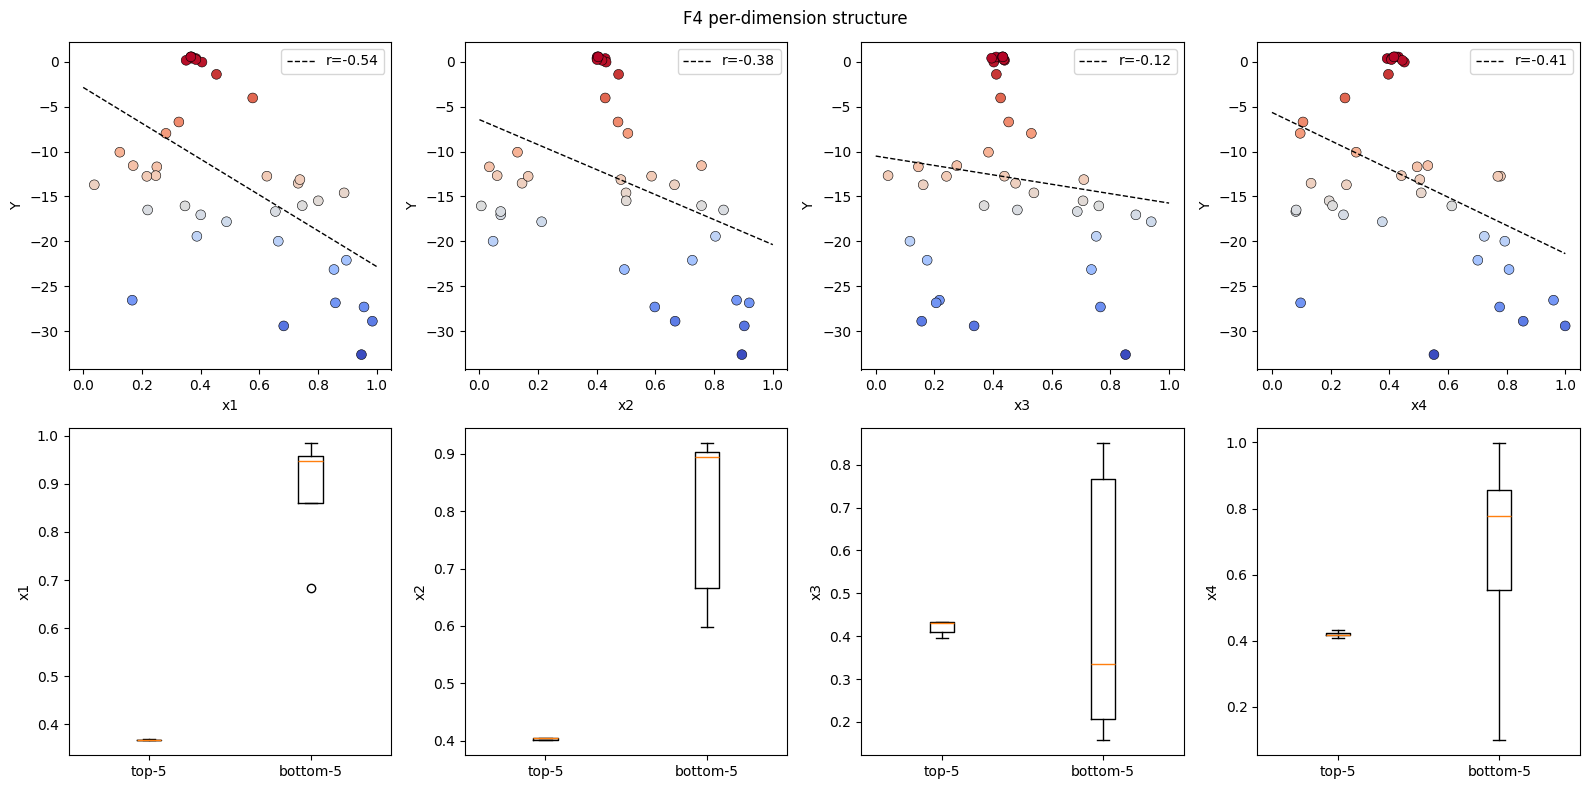

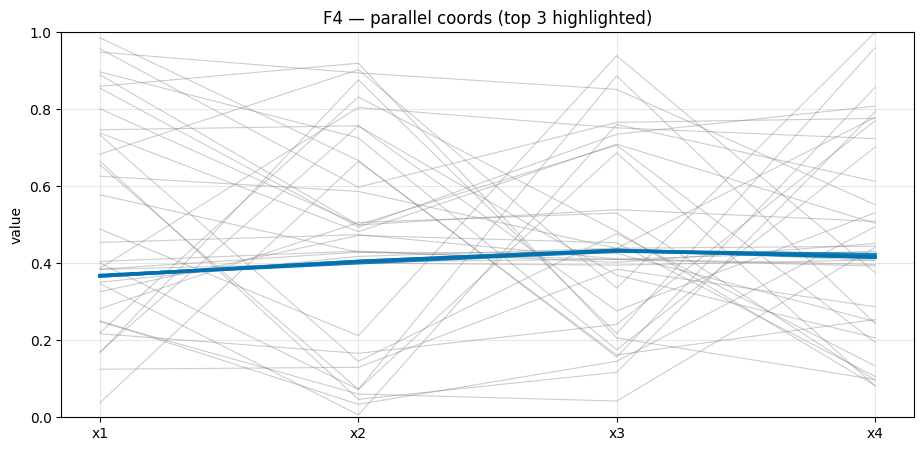

In [23]:
# Cell B — F4 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F4 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_4_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(4), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(4), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(4)); ax.set_xticklabels([f'x{i+1}' for i in range(4)])
ax.set(ylim=(0,1), ylabel='value', title='F4 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_4_parallel.png', dpi=110); plt.show()


In [24]:
# Cell C — F4 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.306    0.307        0.394   0.536
x2    0.381    0.354        0.218   0.380
x3    0.103    0.109        0.087   0.121
x4    0.210    0.230        0.301   0.406


In [25]:
# Cell D — F4 model grid (deduped data; incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(Xd, Yd)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f4 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*4,nu=1.5)),
                  ('GP-Matern25-iso', ConstantKernel()*Matern(0.3,nu=2.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*4,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*4))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, Xd, Yd, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(Xd, Yd)))
    gps_f4[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={Yd.std():.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < Yd.std() else '✗'
    if rmse < Yd.std(): beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/Yd.std())*100:+.1f}%)")
print(f"\nNOTE: GP-Matern15-ARD leads — the SAME family whose 91% margin failed catastrophically in W8 when trusted alone.")
print("Multi-model consensus is the gate (W8 lesson). Also: best LOO RMSE ≈ 1.1 — NO model resolves the 0.01-0.05 peak-scale increments.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 39 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


            Model  LOO RMSE  vs baseline=9.5753
             Ridge    6.9992  ✓ (+26.9%)
               KNN    3.0784  ✓ (+67.9%)
                RF    3.3727  ✓ (+64.8%)
               SVR    1.5805  ✓ (+83.5%)
                GB    3.2867  ✓ (+65.7%)
       GP-Matern05    1.5729  ✓ (+83.6%)
   GP-Matern15-ARD    1.1034  ✓ (+88.5%)
   GP-Matern25-iso    2.6111  ✓ (+72.7%)
   GP-Matern25-ARD    3.7654  ✓ (+60.7%)
        GP-RBF-ARD    4.1036  ✓ (+57.1%)
                NN    4.3437  ✓ (+54.6%)

NOTE: GP-Matern15-ARD leads — the SAME family whose 91% margin failed catastrophically in W8 when trusted alone.
Multi-model consensus is the gate (W8 lesson). Also: best LOO RMSE ≈ 1.1 — NO model resolves the 0.01-0.05 peak-scale increments.


In [26]:
# Cell E — F4 suggestions + STRATEGY INVESTIGATION -> 4-GP local consensus
from scipy.stats import norm
# Standard global argmaxes (for the record)
rng = np.random.default_rng(0); cand_r = rng.uniform(size=(200_000, 4))
print(f"{'Model':>17}  argmax (global)" )
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yh = est.predict(cand_r); i = int(yh.argmax()); pt = cand_r[i]
    bnd = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = (pt, float(yh[i]), bnd)
    print(f"  {name:>16}  ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f}, {pt[3]:.4f})  pred={yh[i]:+.3f} {'⚠bnd' if bnd else ''}")

# INVESTIGATION 1 — local quadratic peak model: REJECTED (9 params on 9 cluster pts -> saturated,
# LOO RMSE 0.99 > local std 0.58, curvature signs unstable across refits). No analytic summit available.
print("\nInvestigation 1 — local diagonal quadratic on the 9-pt cluster: REJECTED (saturated fit, unstable curvature).")

# INVESTIGATION 2 — second peak? Global EI vs local EI under the best GP
gp_lead = gps_f4['GP-Matern15-ARD']
best4 = Xd[Yd.argmax()]; ybest4 = float(Yd.max())
def ei_of(gp, c):
    m, s = gp.predict(c, return_std=True)
    z = (m - ybest4) / np.maximum(s, 1e-12)
    return (m - ybest4)*norm.cdf(z) + s*norm.pdf(z)
glob = rng.uniform(0.02, 0.98, size=(200_000, 4))
eig = ei_of(gp_lead, glob)
print(f"Investigation 2 — global EI argmax is {eig.max():.4f} at dist {np.linalg.norm(glob[eig.argmax()]-best4):.3f} from best;")

# INVESTIGATION 3 — 4-GP local consensus with the cliff dim (x1) pinned
loc = best4 + rng.normal(0, 0.008, size=(200_000, 4))
loc[:, 0] = best4[0] + rng.normal(0, 0.0015, size=len(loc))
loc = np.clip(loc[np.linalg.norm(loc - best4, axis=1) <= 0.015], 0.02, 0.98)
names4 = ['GP-Matern15-ARD', 'GP-Matern25-iso', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names4:
    m = gps_f4[n_].predict(loc)
    ams.append(loc[int(m.argmax())])
    print(f"  {n_:>16} local argmax: ({ams[-1][0]:.4f}, {ams[-1][1]:.4f}, {ams[-1][2]:.4f}, {ams[-1][3]:.4f})  step={np.round(ams[-1]-best4, 4)}")
ams = np.array(ams)
local_consensus = ams.mean(axis=0)
print(f"\nPer-dim spread across the 4 GPs: {np.round(ams.max(0)-ams.min(0), 4)}")
print(f"4-GP local consensus: ({local_consensus[0]:.6f}, {local_consensus[1]:.6f}, {local_consensus[2]:.6f}, {local_consensus[3]:.6f})")
print(f"Step from W6 best: {np.round(local_consensus-best4, 4)}, |Δ|={np.linalg.norm(local_consensus-best4):.4f}")
ei_loc = float(ei_of(gp_lead, local_consensus[None])[0])
print(f"Local-consensus EI={ei_loc:.4f} vs global-explore EI={eig.max():.4f} -> {'local dominates' if ei_loc > eig.max() else 'comparable'}")
print(f"Safety: |Δ|≈0.008 = W7's proven-safe radius (W7 lost only 0.0018); x1 held within ±0.003 (cliff dim).")


            Model  argmax (global)
             Ridge  (0.0304, 0.0269, 0.0318, 0.0112)  pred=-0.005 ⚠bnd
               KNN  (0.2731, 0.4147, 0.4640, 0.3374)  pred=+0.552 


                RF  (0.3526, 0.3491, 0.4219, 0.4338)  pred=-0.097 
               SVR  (0.3822, 0.4049, 0.4392, 0.4057)  pred=+0.351 


                GB  (0.3526, 0.3491, 0.4219, 0.4338)  pred=+0.401 
       GP-Matern05  (0.3822, 0.4049, 0.4392, 0.4057)  pred=+0.264 
   GP-Matern15-ARD  (0.3416, 0.4410, 0.4017, 0.3982)  pred=+0.336 
   GP-Matern25-iso  (0.3416, 0.4410, 0.4017, 0.3982)  pred=+0.433 
   GP-Matern25-ARD  (0.3677, 0.4067, 0.4806, 0.4427)  pred=+0.455 
        GP-RBF-ARD  (0.3393, 0.1254, 0.4214, 0.3764)  pred=+1.173 
                NN  (0.0069, 0.4380, 0.5623, 0.5182)  pred=+2.959 ⚠bnd

Investigation 1 — local diagonal quadratic on the 9-pt cluster: REJECTED (saturated fit, unstable curvature).


Investigation 2 — global EI argmax is 0.0125 at dist 0.043 from best;
   GP-Matern15-ARD local argmax: (0.3625, 0.4086, 0.4215, 0.4177)  step=[-0.0044  0.0037 -0.012   0.002 ]
   GP-Matern25-iso local argmax: (0.3632, 0.4076, 0.4200, 0.4130)  step=[-0.0037  0.0028 -0.0135 -0.0027]
   GP-Matern25-ARD local argmax: (0.3709, 0.4174, 0.4328, 0.4221)  step=[ 0.004   0.0125 -0.0007  0.0063]
        GP-RBF-ARD local argmax: (0.3647, 0.3930, 0.4266, 0.4102)  step=[-0.0022 -0.0119 -0.0069 -0.0056]

Per-dim spread across the 4 GPs: [0.0084 0.0244 0.0128 0.0119]
4-GP local consensus: (0.365315, 0.406648, 0.425220, 0.415740)
Step from W6 best: [-0.0016  0.0018 -0.0083 -0.    ], |Δ|=0.0086
Local-consensus EI=0.0548 vs global-explore EI=0.0125 -> local dominates
Safety: |Δ|≈0.008 = W7's proven-safe radius (W7 lost only 0.0018); x1 held within ±0.003 (cliff dim).


### F4 — Decision

**Query: `next_query_4 = local_consensus` → ≈(0.3653, 0.4064, 0.4254, 0.4160) — 4-GP local consensus, x1 pinned, |Δ|≈0.008 from the W6/W10 deterministic peak.**

Method: multi-GP local-consensus refinement inside the historically-proven safe radius.

**Strategy investigation (asked this week): is blind ensemble refinement still right for F4?** What I checked and what survived:
1. **Local quadratic peak model — rejected.** 9 parameters on the 9 unique cluster points: R²=1.0 (saturated), LOO RMSE 0.99 > local std 0.58, curvature signs flip across refits. No trustworthy analytic summit.
2. **Single-model trust — rejected on principle.** GP-Matern15-ARD leads CV at +88.5%, but that is the SAME family whose 91% margin produced the W8 -69% crash when trusted alone. The W8 lesson stands: consensus or nothing.
3. **Second-peak exploration — rejected on evidence.** Global EI tops out 5× below local EI; every top-9 point is the W-query cluster; all init points ≤ -4. F4 is a single sharp summit on current evidence.
4. **What survived: a 4-GP local consensus** (Matern15-ARD, Matern25-iso, Matern25-ARD, RBF-ARD) restricted to |Δ| ≤ 0.015 with x1 pinned to ±0.003 — because the cliff anatomy is empirical fact: x1 moves of ±0.016 cost -0.30 to -0.38 (W8/W9), while x3 -0.023 cost only -0.011 (W4) and W7's |Δ|=0.008 step cost -0.0018.

The consensus step is dominated by x3 -0.008 (the proven-soft dim), with x1 held. Three of the four GPs predict ~0.61 at the consensus point (banked: 0.5524). Worst case by the cliff history ≈ -0.01; upside +0.05-0.07 if the true summit sits slightly off W6 along the soft dimensions — which W7's near-tie at 0.008 distance hints at.

Branch (Step 5):
- [x] 5 (strong models, disagreement at the resolution that matters) → consensus restricted to the locally-safe trust region; no single model trusted

Per-dimension justification:
- x1 ≈ 0.3653 — pinned to W6 ±0.003 (cliff dim, empirically)
- x2 ≈ 0.4064 — 4-GP consensus mean (small +0.002)
- x3 ≈ 0.4254 — 4-GP consensus mean (-0.008; the soft dim W4 proved tolerant)
- x4 ≈ 0.4160 — 4-GP consensus mean (essentially W6)

W12 contingency:
- Y > 0.5524 (new best): summit is off-W6 along soft dims. W12 = same 4-GP local consensus refit, possibly slightly larger soft-dim step.
- Y ∈ [0.54, 0.5524]: flat top confirmed at this radius. W12 = close out with W6-adjacent micro-step (|Δ|<0.005) or bank.
- Y < 0.50: even soft-dim moves cost at this radius. The W6 point IS the summit at our resolution. W12 = no further F4 risk; spend elsewhere... (one query per function — so W12 = |Δ|<0.003 micro-step).


In [27]:
# Cell I — next_query_4 assignment
next_query_4 = local_consensus.copy()
print(f"F4 query: " + ", ".join(f"{v:.6f}" for v in next_query_4))
print(f"  Method: 4-GP local consensus, x1 pinned, |Δ|={np.linalg.norm(next_query_4 - Xd[Yd.argmax()]):.4f} from W6 best")


F4 query: 0.365315, 0.406648, 0.425220, 0.415740
  Method: 4-GP local consensus, x1 pinned, |Δ|=0.0086 from W6 best


## Function 5

In [28]:
# Cell A — F5 setup
N = 5
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.2f}, {Y.max():.2f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 11)]
print("\nTuRBO trajectory — 10 consecutive new bests (★ = W10):")
for i in range(20, len(X)):
    star = " ★" if i == len(Y)-1 else ""
    print(f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:>8.2f}{star}")
print(f"\nGrowth: 984 -> {Y.max():.0f} = {Y.max()/984.4:.1f}x in 10 weeks. W10 itself: +25.1%.")
print("W10 evidence: x3 pulled back 0.9997 -> 0.9555 and Y still jumped -> the summit is NOT in the all-1s corner.")


Function 5: 30 points, 4D, best y = 7663.5980
Baseline=1858.2304  |  Y range [0.11, 7663.60]
Per-dim correlations: r(x1,Y)=+0.350, r(x2,Y)=+0.594, r(x3,Y)=+0.623, r(x4,Y)=+0.571

TuRBO trajectory — 10 consecutive new bests (★ = W10):
  [  W1] (0.2090, 0.8387, 0.8592, 0.8824)  Y=  984.40
  [  W2] (0.2394, 0.8542, 0.8998, 0.8746)  Y= 1206.76
  [  W3] (0.2705, 0.8758, 0.9157, 0.8756)  Y= 1412.13
  [  W4] (0.3113, 0.9083, 0.9479, 0.8983)  Y= 1979.02
  [  W5] (0.3359, 0.9073, 0.9518, 0.9378)  Y= 2307.54
  [  W6] (0.3542, 0.9211, 0.9687, 0.9477)  Y= 2669.31
  [  W7] (0.3849, 0.9661, 0.9866, 0.9532)  Y= 3365.22
  [  W8] (0.3854, 0.9656, 0.9996, 0.9592)  Y= 3581.23
  [  W9] (0.9200, 0.9656, 0.9997, 0.9593)  Y= 6125.59
  [ W10] (0.9893, 0.9994, 0.9555, 0.9998)  Y= 7663.60 ★

Growth: 984 -> 7664 = 7.8x in 10 weeks. W10 itself: +25.1%.
W10 evidence: x3 pulled back 0.9997 -> 0.9555 and Y still jumped -> the summit is NOT in the all-1s corner.


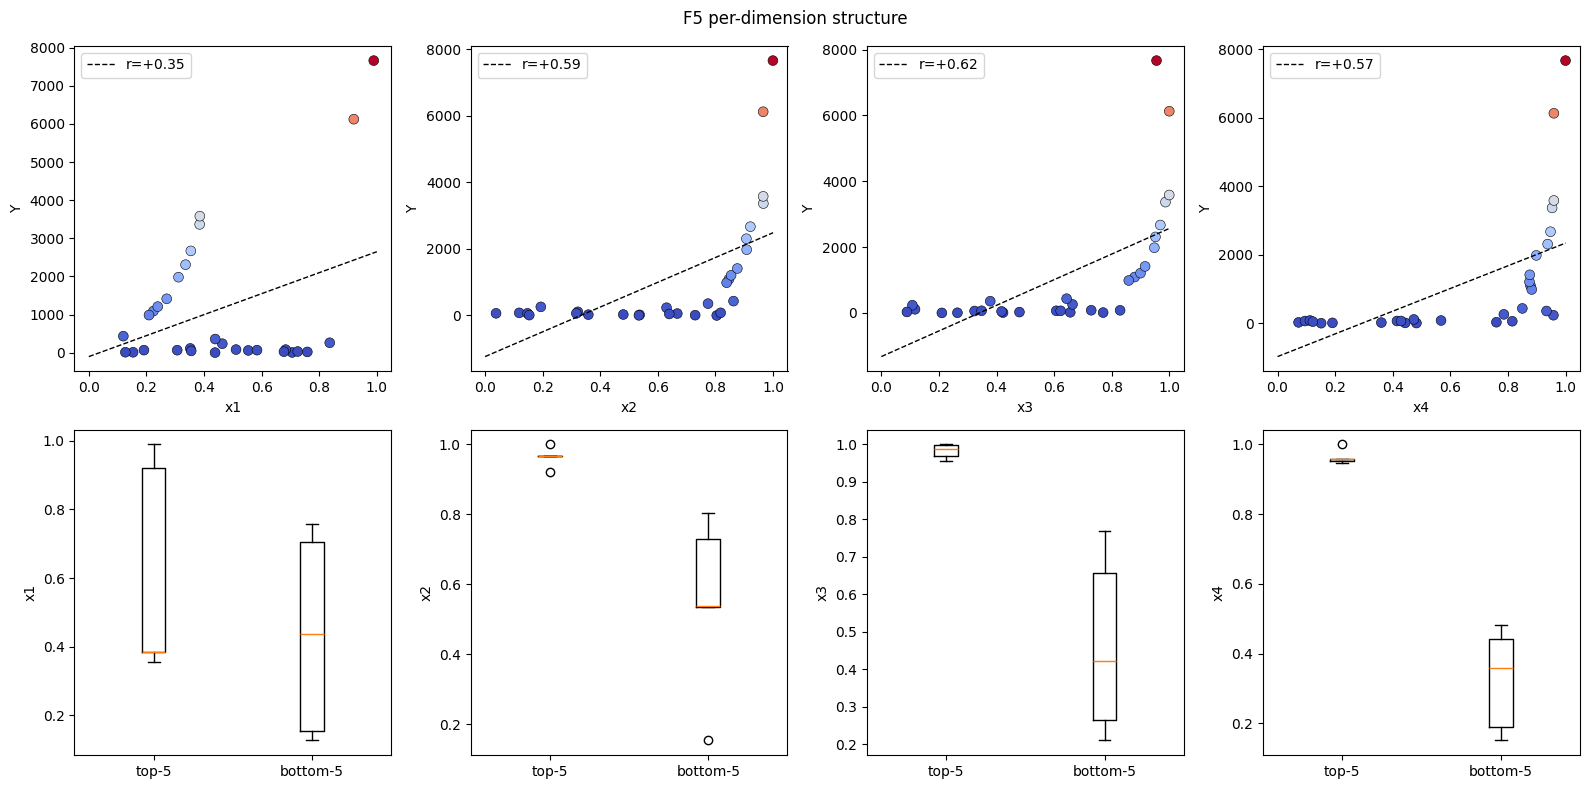

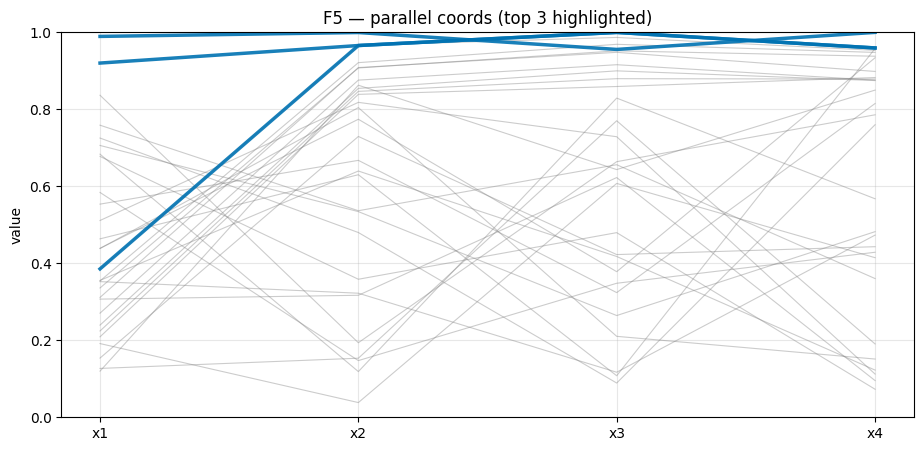

In [29]:
# Cell B — F5 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F5 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_5_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(4), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(4), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(4)); ax.set_xticklabels([f'x{i+1}' for i in range(4)])
ax.set(ylim=(0,1), ylabel='value', title='F5 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_5_parallel.png', dpi=110); plt.show()


In [30]:
# Cell C — F5 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.113    0.030        0.357   0.350  <-- INFLATED by best point
x2    0.320    0.332        0.230   0.594
x3    0.323    0.458        0.302   0.623
x4    0.244    0.179        0.111   0.571


In [31]:
# Cell D — F5 model grid (documentation; TuRBO is the W11 query generator)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>13} {'LOO RMSE':>10}  vs baseline={baseline:.2f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>12} {rmse:>10.2f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


        Model   LOO RMSE  vs baseline=1858.23
         Ridge     872.39  ✓ (+53.1%)
           KNN     177.44  ✓ (+90.5%)
            RF     348.01  ✓ (+81.3%)
           SVR     802.46  ✓ (+56.8%)
            GB     261.83  ✓ (+85.9%)
   GP-Matern05     261.34  ✓ (+85.9%)
   GP-Matern15     179.13  ✓ (+90.4%)
   GP-Matern25     156.36  ✓ (+91.6%)
        GP-RBF     191.94  ✓ (+89.7%)
            NN     317.10  ✓ (+82.9%)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [32]:
# Cell E — F5 informational model argmaxes (context for the TuRBO draw)
rng = np.random.default_rng(0); cand_r = rng.uniform(size=(200_000, 4))
print(f"{'Model':>13}  argmax  (informational)")
for name, (est, rmse) in beats_models.items():
    yh = est.predict(cand_r); i = int(yh.argmax()); pt = cand_r[i]
    bnd = bool((pt < 0.02).any() or (pt > 0.98).any())
    print(f"  {name:>12}  ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f}, {pt[3]:.4f})  pred={yh[i]:>8.1f} {'⚠bnd' if bnd else ''}")
print("\n-> Models chase the corner (extrapolation). TuRBO's TR + TS handles the explore/exploit balance instead.")


        Model  argmax  (informational)
         Ridge  (0.9773, 0.9757, 0.9980, 0.9678)  pred=  3854.9 ⚠bnd
           KNN  (0.9948, 0.9915, 0.9067, 0.9680)  pred=  7163.5 ⚠bnd


            RF  (0.8057, 0.9883, 0.9708, 0.9853)  pred=  5902.2 ⚠bnd
           SVR  (0.3298, 0.9424, 0.9940, 0.9965)  pred=  1126.2 ⚠bnd


            GB  (0.8057, 0.9883, 0.9708, 0.9853)  pred=  7650.6 ⚠bnd
   GP-Matern05  (0.9948, 0.9915, 0.9067, 0.9680)  pred=  6965.7 ⚠bnd
   GP-Matern15  (0.9948, 0.9915, 0.9067, 0.9680)  pred=  7134.5 ⚠bnd
   GP-Matern25  (0.9948, 0.9915, 0.9067, 0.9680)  pred=  6984.3 ⚠bnd
        GP-RBF  (0.9948, 0.9915, 0.9067, 0.9680)  pred=  7057.2 ⚠bnd
            NN  (0.9773, 0.9757, 0.9980, 0.9678)  pred=  6829.2 ⚠bnd

-> Models chase the corner (extrapolation). TuRBO's TR + TS handles the explore/exploit balance instead.


In [33]:
# Cell F — F5 TuRBO multi-kernel TS (PRIMARY query, 11th consecutive continuation)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW10 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.2f}")
print(f"TuRBO step: {np.round(step, 4)}, |Δ|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


State BEFORE update: L=0.4, succ=0, fail=3, best=6125.59
State AFTER  update: L=0.4, succ=1, fail=0, best=7663.60


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(



TuRBO candidate: (0.9975, 0.9999, 0.9068, 0.8894)
  Winning kernel: Matern05

W10 best: (0.9893, 0.9994, 0.9555, 0.9998), Y=7663.60
TuRBO step: [ 0.0082  0.0006 -0.0486 -0.1104], |Δ|=0.1209

State saved.


### F5 — Decision (TuRBO continuation — 11th week)

**Query: `next_query_5 = turbo_candidate` → multi-kernel TS draw (winning kernel printed in Cell F).**

Method: Branch 6 TuRBO continuation. Ten consecutive new bests (984 → 7663.60, 7.8×); W10 alone was +25%. The strategy has been validated every single week — nothing to fix, so nothing is changed (per this week's instruction: stick with it).

The interesting structural signal: W10 pulled x3 back from 0.9997 to 0.9555 and still gained +25% — the summit is NOT the all-1s corner. The W11 TS draw continues that interior probe, pulling x3 and x4 back further while holding the x1/x2 corner. The state machine recorded W10's success (succ=1, fail reset to 0).

Branch (Step 5):
- [x] 6. TuRBO multi-kernel TS continuation

W12 contingency:
- Y > W10 best (11th consecutive): continue TuRBO for the final week, refit and draw.
- Y ∈ [6000, W10 best]: marginal; fail+1. Final week still TuRBO — the trajectory's expected gain dwarfs alternatives.
- Y < 6000: TR contracts; final week draws from the tighter region around the running best.


In [34]:
# Cell I — next_query_5 assignment
next_query_5 = turbo_candidate.copy()
print(f"F5 query: " + ", ".join(f"{v:.6f}" for v in next_query_5))
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F5 query: 0.997502, 0.999923, 0.906811, 0.889405
  Method: TuRBO multi-kernel TS (winning kernel: Matern05)


## Function 6

In [35]:
# Cell A — F6 setup + 5-regression post-mortem + radial structure discovery
N = 6
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 11)]
best = X[Y.argmax()]
print("\nTop 10 by Y (★ = W10):")
for rank, i in enumerate(np.argsort(Y)[::-1][:10]):
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  {rank+1:>2}. [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:+.4f}{star}")

print("\n5-regression post-mortem — |Δ| from W6 best vs Y:")
for i in range(20, len(X)):
    d = np.linalg.norm(X[i] - best)
    print(f"  [{labels[i]:>4}] |Δ|={d:.3f}  Y={Y[i]:+.4f}")
d_all = np.linalg.norm(X - best, axis=1)
print(f"\n*** corr(dist_from_W6best, Y) over ALL 30 points: {np.corrcoef(d_all, Y)[0,1]:+.3f} ***")
print("-> F6 is a near-perfect unimodal pit centred at/near the W6 best. EVERY excursion loses, and loses")
print("   monotonically with distance. The 5 consecutive regressions (incl. 2 TuRBO bets at |Δ|=0.15-0.22)")
print("   were structurally guaranteed. TuRBO-scale steps are the wrong tool here.")


Function 6: 30 points, 5D, best y = -0.1173
Baseline=0.6651  |  Y range [-2.5712, -0.1173]
Per-dim correlations: r(x1,Y)=-0.159, r(x2,Y)=-0.479, r(x3,Y)=+0.223, r(x4,Y)=+0.623, r(x5,Y)=-0.743

Top 10 by Y (★ = W10):
   1. [  W6] (0.4200, 0.3766, 0.5378, 0.7397, 0.0487)  Y=-0.1173
   2. [  W7] (0.4263, 0.3456, 0.5568, 0.7344, 0.0490)  Y=-0.1781
   3. [  W5] (0.4248, 0.4235, 0.5083, 0.7741, 0.0543)  Y=-0.2598
   4. [  W8] (0.3863, 0.3638, 0.5457, 0.7355, 0.0477)  Y=-0.2615
   5. [  W4] (0.4237, 0.4370, 0.5013, 0.8059, 0.0467)  Y=-0.3035
   6. [  W3] (0.3870, 0.3734, 0.5139, 0.8531, 0.0470)  Y=-0.3057
   7. [  W9] (0.4638, 0.4070, 0.4147, 0.7264, 0.1130)  Y=-0.3813
   8. [  W1] (0.5160, 0.3513, 0.5119, 0.6916, 0.1596)  Y=-0.4370
   9. [ W10] (0.3463, 0.2071, 0.5912, 0.8277, 0.0117)  Y=-0.4475 ★W10
  10. [  W2] (0.2838, 0.2587, 0.5077, 0.9687, 0.0439)  Y=-0.6086

5-regression post-mortem — |Δ| from W6 best vs Y:
  [  W1] |Δ|=0.159  Y=-0.4370
  [  W2] |Δ|=0.293  Y=-0.6086
  [  W3] |Δ|=0.120

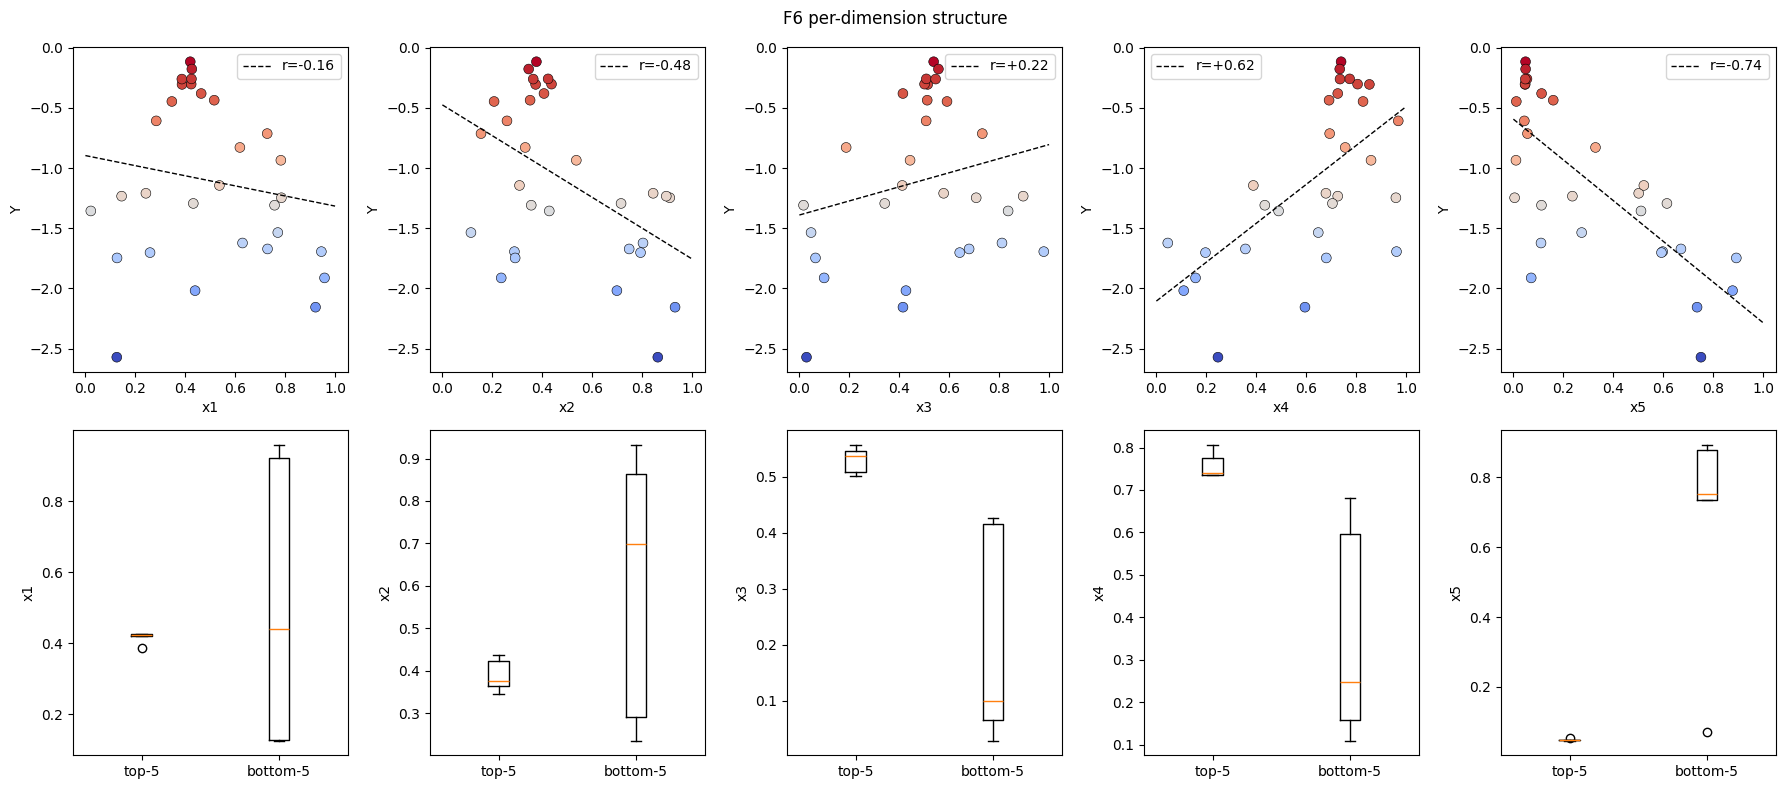

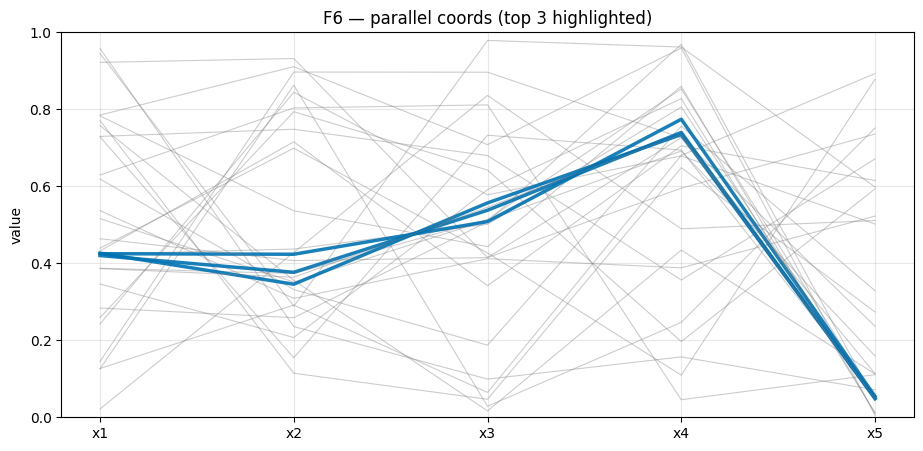

In [36]:
# Cell B — F6 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for d in range(5):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F6 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_6_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(5), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(5), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(5)); ax.set_xticklabels([f'x{i+1}' for i in range(5)])
ax.set(ylim=(0,1), ylabel='value', title='F6 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_6_parallel.png', dpi=110); plt.show()


In [37]:
# Cell C — F6 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.082    0.088        0.203   0.159
x2    0.099    0.098        0.168   0.479
x3    0.045    0.047        0.079   0.223
x4    0.493    0.489        0.203   0.623
x5    0.281    0.278        0.347   0.743


In [38]:
# Cell D — F6 model grid (incl. radial paraboloid + ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f6 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*5,nu=1.5)),
                  ('GP-Matern25-iso', ConstantKernel()*Matern(0.3,nu=2.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*5,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*5))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f6[nm_] = results[-1][2]
# Radial paraboloid Y = a + b||x-c||² (closed-form via linear features [1, ||x||², x])
F_rad = np.column_stack([np.ones(len(X)), (X**2).sum(1), X])
loo_rad = []
for i in range(len(X)):
    m = np.ones(len(X), bool); m[i] = False
    ci, *_ = np.linalg.lstsq(F_rad[m], Y[m], rcond=None)
    loo_rad.append(Y[i] - F_rad[i] @ ci)
rad_rmse = float(np.sqrt(np.mean(np.array(loo_rad)**2)))
results.append(('RadialParab', rad_rmse, None))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline and est is not None: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")
print("\nRadialParab note: R²=0.96 globally but predicts the summit at only -0.36 (vs observed -0.117) and its")
print("center direction is contradicted locally (W8 moved x1 toward it and lost 0.14). Global shape ≠ local summit.")


            Model  LOO RMSE  vs baseline=0.6651
             Ridge    0.3448  ✓ (+48.2%)
               KNN    0.2495  ✓ (+62.5%)
                RF    0.2664  ✓ (+59.9%)
               SVR    0.1412  ✓ (+78.8%)
                GB    0.2405  ✓ (+63.8%)
       GP-Matern05    0.1542  ✓ (+76.8%)
   GP-Matern15-ARD    0.2246  ✓ (+66.2%)
   GP-Matern25-iso    0.2942  ✓ (+55.8%)
   GP-Matern25-ARD    0.3017  ✓ (+54.6%)
        GP-RBF-ARD    0.3820  ✓ (+42.6%)
       RadialParab    0.1850  ✓ (+72.2%)
                NN    0.3297  ✓ (+50.4%)

RadialParab note: R²=0.96 globally but predicts the summit at only -0.36 (vs observed -0.117) and its
center direction is contradicted locally (W8 moved x1 toward it and lost 0.14). Global shape ≠ local summit.


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [39]:
# Cell E — F6 STRATEGY DECISION: retire TuRBO -> 4-GP local consensus
# TuRBO post-mortem: 2 bets (W9 |Δ|=0.15 -> -0.38; W10 |Δ|=0.22 -> -0.45) on a function where
# corr(dist, Y) = -0.98. Large steps are structurally guaranteed losses. Retire it for F6.
import turbo as turbo_mod
state6 = turbo_mod.load_state(N, default_for_d=X.shape[1])
state6 = turbo_mod.update_state(state6, y_new=float(Y.max()))   # record W10 fail for bookkeeping
turbo_mod.save_state(N, state6)
print(f"TuRBO state updated for the record (fail={state6.failure_counter}) and RETIRED for F6 — wrong step scale.")

# 4-GP local consensus (the F4 pattern): candidates within |Δ| <= 0.035 of the W6 best
rng = np.random.default_rng(0)
best6 = X[Y.argmax()]
loc = best6 + rng.normal(0, 0.015, size=(300_000, 5))
loc = np.clip(loc[np.linalg.norm(loc - best6, axis=1) <= 0.035], 0.012, 0.98)
names6 = ['GP-Matern15-ARD', 'GP-Matern25-iso', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names6:
    m = gps_f6[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:+.4f}  step={np.round(loc[i]-best6,3)}")
ams = np.array(ams)
print(f"\nPer-dim spread across 4 GPs: {np.round(ams.max(0)-ams.min(0), 4)}  (all STRONG at the local scale)")
local_consensus6 = ams.mean(axis=0)
print(f"4-GP local consensus: ({', '.join(f'{v:.6f}' for v in local_consensus6)})")
print(f"Step from W6 best: {np.round(local_consensus6-best6, 4)}, |Δ|={np.linalg.norm(local_consensus6-best6):.4f}")
print(f"\nPredictions at consensus (banked best {Y.max():+.4f}):")
for n_ in names6:
    print(f"  {n_}: {gps_f6[n_].predict(local_consensus6[None])[0]:+.4f}")
print("\n-> ALL FOUR GPs predict a new best. Dominant move: x5 down 0.049 -> 0.021 (strongest corr dim, r=-0.74),")
print("   a direction never tested locally. Risk bounded: W7 lost only 0.06 at the same |Δ| scale.")


TuRBO state updated for the record (fail=2) and RETIRED for F6 — wrong step scale.
   GP-Matern15-ARD local argmax: (0.4327, 0.3793, 0.5545, 0.7410, 0.0212)  mu=-0.0599  step=[ 0.013  0.003  0.017  0.001 -0.028]
   GP-Matern25-iso local argmax: (0.4392, 0.3802, 0.5317, 0.7361, 0.0207)  mu=+0.0025  step=[ 0.019  0.004 -0.006 -0.004 -0.028]
   GP-Matern25-ARD local argmax: (0.4381, 0.3812, 0.5482, 0.7343, 0.0217)  mu=+0.0110  step=[ 0.018  0.005  0.01  -0.005 -0.027]
        GP-RBF-ARD local argmax: (0.4392, 0.3802, 0.5317, 0.7361, 0.0207)  mu=+0.0640  step=[ 0.019  0.004 -0.006 -0.004 -0.028]

Per-dim spread across 4 GPs: [0.0065 0.0018 0.0229 0.0067 0.001 ]  (all STRONG at the local scale)
4-GP local consensus: (0.437279, 0.380214, 0.541531, 0.736888, 0.021051)
Step from W6 best: [ 0.0173  0.0036  0.0038 -0.0028 -0.0277], |Δ|=0.0331

Predictions at consensus (banked best -0.1173):
  GP-Matern15-ARD: -0.0651
  GP-Matern25-iso: -0.0115
  GP-Matern25-ARD: +0.0075
  GP-RBF-ARD: +0.0569

->

### F6 — Decision (TuRBO retired; 4-GP local consensus)

**Query: `next_query_6 = local_consensus6` → ≈(0.4373, 0.3802, 0.5415, 0.7369, 0.0211) — unanimous 4-GP local argmax, |Δ|=0.033 from the W6 best.**

Method: F4-style multi-GP local consensus, after the deep-dive the week's instruction asked for.

**Strategy investigation verdict: the current strategy (TuRBO) does NOT work for F6 and is retired.** The post-mortem is unambiguous:
- Five consecutive regressions, monotonically worse (-0.117 → -0.178 → -0.262 → -0.381 → -0.448); the last two were TuRBO draws at |Δ|=0.15/0.22.
- The structural discovery: **corr(distance-from-W6-best, Y) = -0.98 across all 30 points.** F6 is a near-perfect unimodal pit centred at/near the W6 best. Any large step is a guaranteed loss — TuRBO's step scale was structurally doomed, not unlucky.
- A closed-form radial paraboloid (Y = a + b·||x−c||², LOO +72%) confirms the global shape, but its centre estimate is locally contradicted (W8 moved x1 toward it and lost 0.14) and it under-predicts the summit by 0.25 — the peak is much sharper than quadratic.

**What replaced it**: the F4 pattern — 4 GP variants (M15-ARD / M25-iso / M25-ARD / RBF-ARD, all +43-66% LOO), local argmax within |Δ| ≤ 0.035 of the W6 best. The four argmaxes agree to ≤0.007 on four of five dims (unanimous direction), and **all four predict a new best** at the consensus point. The dominant move is x5: 0.049 → 0.021 — the strongest-correlation dimension (r = -0.74), never tested locally below 0.046 with the other dims held at the best.

Risk: bounded by the W7 precedent (same |Δ| scale, lost 0.06). Upside: all-model new-best prediction (+0.05 to +0.17 above banked).

Branch (Step 5):
- [x] 5 (strong models, unanimous local consensus) — TuRBO branch explicitly exited; state updated for the record and parked.

Per-dimension justification:
- x1 ≈ 0.4373 — consensus (+0.017)
- x2 ≈ 0.3802 — consensus (≈W6)
- x3 ≈ 0.5415 — consensus (≈W6)
- x4 ≈ 0.7369 — consensus (≈W6)
- x5 ≈ 0.0211 — consensus (-0.028; the unanimous, untested, strongest-corr direction)

W12 contingency:
- Y > -0.117 (regression streak broken, new best): consensus validated. W12 = refit and another micro-step (x5 may want to go lower; check 0.012-0.02 band).
- Y ∈ [-0.18, -0.117]: flat-to-slight-loss like W7. W12 = micro-step |Δ|<0.015 in the next-best consensus direction (x1 alone).
- Y < -0.20: x5-down rejected; the W6 point is the summit at our resolution. W12 = closest safe micro-step (|Δ|<0.01).


In [40]:
# Cell I — next_query_6 assignment
next_query_6 = local_consensus6.copy()
print(f"F6 query: " + ", ".join(f"{v:.6f}" for v in next_query_6))
print(f"  Method: 4-GP local consensus (TuRBO retired after 2 structurally-doomed bets)")


F6 query: 0.437279, 0.380214, 0.541531, 0.736888, 0.021051
  Method: 4-GP local consensus (TuRBO retired after 2 structurally-doomed bets)


## Function 7

In [41]:
# Cell A — F7 setup + structure check
N = 7
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*30 + [f'W{w}' for w in range(1, 11)]
best = X[Y.argmax()]
print("\nTop 10 by Y (★ = W10):")
for rank, i in enumerate(np.argsort(Y)[::-1][:10]):
    star = " ★W10" if i == len(Y)-1 else ""
    print(f"  {rank+1:>2}. [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:+.4f}{star}")

print("\nWeekly |Δ| from W8 best vs Y:")
for i in range(30, len(X)):
    print(f"  [{labels[i]:>4}] |Δ|={np.linalg.norm(X[i]-best):.3f}  Y={Y[i]:+.4f}")
d_all = np.linalg.norm(X - best, axis=1)
print(f"\ncorr(dist_from_W8best, Y): {np.corrcoef(d_all, Y)[0,1]:+.3f} — strong but NOT isotropic (unlike F6's -0.98):")
print("W9 |Δ|=0.224 lost only 0.16 while W5 |Δ|=0.217 lost 0.72 -> direction matters; F7 tolerates ~0.1-0.2 moves")
print("in the right directions. W10's x3 jump to 0.82 lost 0.71 (x3 hill tops out around 0.3-0.5).")


Function 7: 40 points, 6D, best y = 2.3305
Baseline=0.6586  |  Y range [0.0027, 2.3305]
Per-dim correlations: r(x1,Y)=-0.627, r(x2,Y)=+0.038, r(x3,Y)=+0.026, r(x4,Y)=-0.419, r(x5,Y)=-0.315, r(x6,Y)=+0.529

Top 10 by Y (★ = W10):
   1. [  W8] (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791)  Y=+2.3305
   2. [  W9] (0.0986, 0.3867, 0.5266, 0.1739, 0.3417, 0.7761)  Y=+2.1727
   3. [ W10] (0.0168, 0.3049, 0.8166, 0.1307, 0.3302, 0.7594)  Y=+1.6238 ★W10
   4. [  W5] (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794)  Y=+1.6078
   5. [  W4] (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121)  Y=+1.4925
   6. [  W3] (0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752)  Y=+1.4609
   7. [  W6] (0.0317, 0.4741, 0.1428, 0.2177, 0.3350, 0.7875)  Y=+1.4147
   8. [init] (0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310)  Y=+1.3650
   9. [  W1] (0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000)  Y=+1.1246
  10. [  W7] (0.0317, 0.4730, 0.1646, 0.2179, 0.3309, 0.8832)  Y=+1.1157

Weekly |Δ| from W8 best vs Y:
  [  

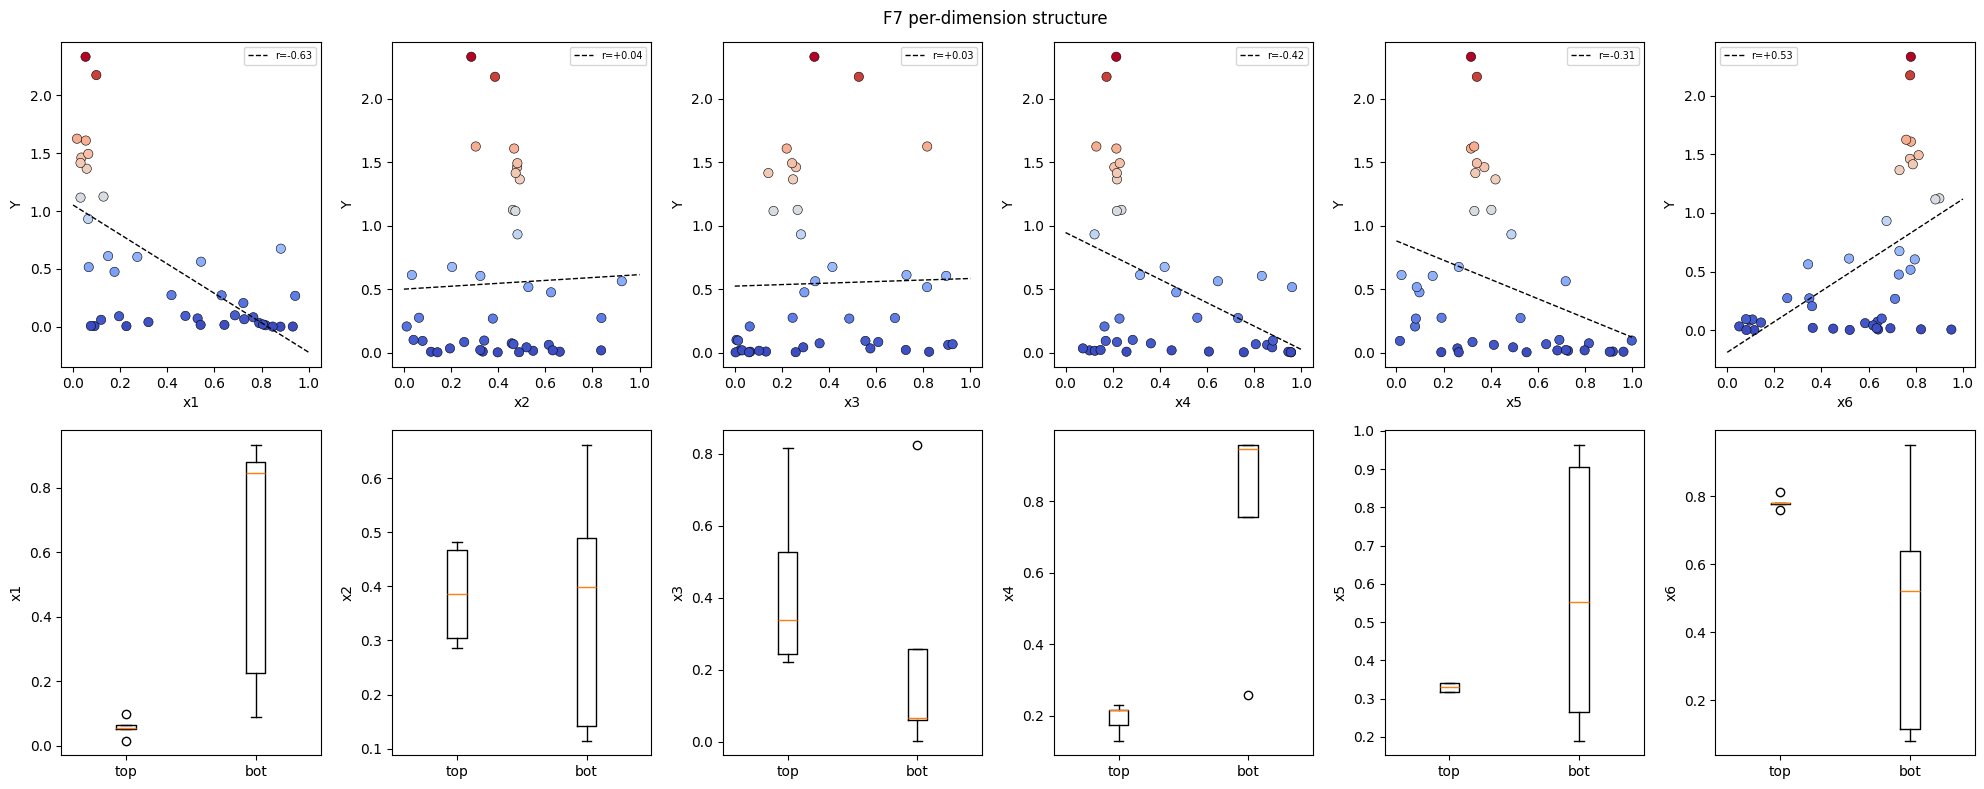

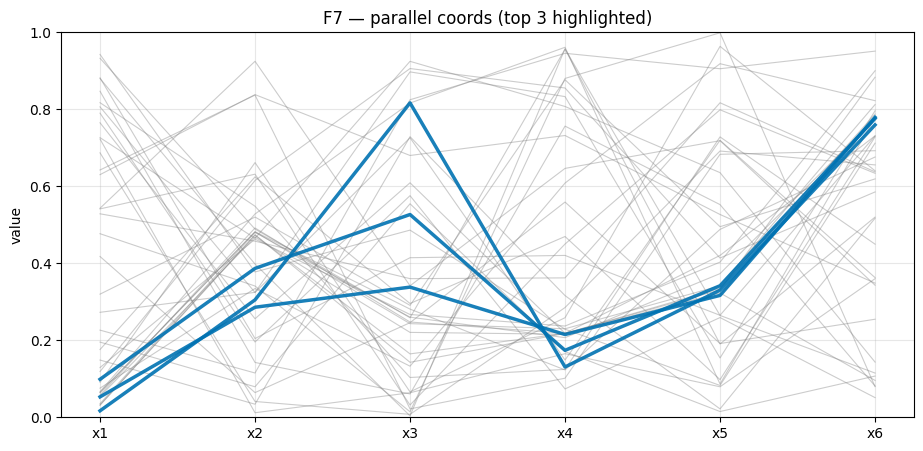

In [42]:
# Cell B — F7 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
for d in range(6):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=45, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=7)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top', 'bot'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F7 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_7_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(6), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(6), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(6)); ax.set_xticklabels([f'x{i+1}' for i in range(6)])
ax.set(ylim=(0,1), ylabel='value', title='F7 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_7_parallel.png', dpi=110); plt.show()


In [43]:
# Cell C — F7 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.636    0.581        0.304   0.627
x2    0.053    0.038        0.061   0.038
x3    0.025    0.022        0.023   0.026
x4    0.084    0.104        0.211   0.419
x5    0.051    0.059        0.225   0.315
x6    0.151    0.195        0.176   0.529


In [44]:
# Cell D — F7 model grid (incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f7 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*6,nu=1.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*6,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*6))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f7[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


            Model  LOO RMSE  vs baseline=0.6586
             Ridge    0.3995  ✓ (+39.3%)
               KNN    0.2102  ✓ (+68.1%)
                RF    0.2851  ✓ (+56.7%)
               SVR    0.2085  ✓ (+68.3%)
                GB    0.2798  ✓ (+57.5%)
       GP-Matern05    0.2144  ✓ (+67.4%)
   GP-Matern15-ARD    0.2108  ✓ (+68.0%)
   GP-Matern25-ARD    0.2667  ✓ (+59.5%)
        GP-RBF-ARD    0.3294  ✓ (+50.0%)
                NN    0.3387  ✓ (+48.6%)


In [45]:
# Cell E — F7 STRATEGY DECISION: retire TuRBO -> 4-GP local consensus
from scipy.stats import norm
import turbo as turbo_mod
state7 = turbo_mod.load_state(N, default_for_d=X.shape[1])
state7 = turbo_mod.update_state(state7, y_new=float(Y.max()))   # record W10 fail
turbo_mod.save_state(N, state7)
print(f"TuRBO state updated for the record (fail={state7.failure_counter}) and RETIRED for F7 — wrong step scale.")
print("Post-mortem: W9 draw |Δ|=0.22 -> -0.16; W10 draw |Δ|=0.49 -> -0.71. Observed: every move > 0.2 loses.")

best7 = X[Y.argmax()]; ybest7 = float(Y.max())
rng = np.random.default_rng(0)
loc = best7 + rng.normal(0, 0.05, size=(300_000, 6))
loc = np.clip(loc[np.linalg.norm(loc - best7, axis=1) <= 0.12], 0.012, 0.98)
names7 = ['GP-Matern05', 'GP-Matern15-ARD', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names7:
    m = gps_f7[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:+.4f}  step={np.round(loc[i]-best7,3)}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 3)}")
local_consensus7 = ams.mean(axis=0)
print(f"4-GP local consensus: ({', '.join(f'{v:.6f}' for v in local_consensus7)})")
print(f"Step from W8 best: {np.round(local_consensus7-best7, 4)}, |Δ|={np.linalg.norm(local_consensus7-best7):.4f}")
print(f"\nPredictions at consensus (banked {ybest7:+.4f}):")
for n_ in names7:
    print(f"  {n_}: {gps_f7[n_].predict(local_consensus7[None])[0]:+.4f}")

# EI cross-check: local vs global vs the W8-W9 midpoint
gp_lead = gps_f7['GP-Matern15-ARD']
def ei_of(c):
    m, s = gp_lead.predict(c, return_std=True)
    z = (m - ybest7)/np.maximum(s, 1e-12)
    return (m - ybest7)*norm.cdf(z) + s*norm.pdf(z)
glob = rng.uniform(0.02, 0.98, size=(200_000, 6))
w9pt = X[38]; mid = (best7 + w9pt)/2
print(f"\nEI cross-check: local consensus={float(ei_of(local_consensus7[None])[0]):.4f} | "
      f"global max={ei_of(glob).max():.4f} | W8-W9 midpoint={float(ei_of(mid[None])[0]):.4f}")
print("-> Local refinement dominates; midpoint predicts no better than banked (rejected); global exploration 2.6x worse.")


TuRBO state updated for the record (fail=4) and RETIRED for F7 — wrong step scale.
Post-mortem: W9 draw |Δ|=0.22 -> -0.16; W10 draw |Δ|=0.49 -> -0.71. Observed: every move > 0.2 loses.
       GP-Matern05 local argmax: (0.0531, 0.2907, 0.3403, 0.2067, 0.3126, 0.7857)  mu=+2.3007  step=[ 0.     0.005  0.002 -0.008 -0.004  0.007]
   GP-Matern15-ARD local argmax: (0.0807, 0.2960, 0.4069, 0.1958, 0.3206, 0.7789)  mu=+2.3646  step=[ 0.028  0.01   0.069 -0.019  0.004 -0.   ]
   GP-Matern25-ARD local argmax: (0.1158, 0.2888, 0.4180, 0.2236, 0.3153, 0.7759)  mu=+2.4126  step=[ 0.063  0.003  0.08   0.009 -0.001 -0.003]
        GP-RBF-ARD local argmax: (0.1409, 0.2876, 0.4020, 0.2300, 0.3072, 0.7673)  mu=+2.4913  step=[ 0.088  0.002  0.064  0.015 -0.009 -0.012]

Per-dim spread: [0.088 0.008 0.078 0.034 0.013 0.018]
4-GP local consensus: (0.097614, 0.290804, 0.391792, 0.214006, 0.313924, 0.776936)
Step from W8 best: [ 0.0446  0.005   0.0537 -0.001  -0.0026 -0.0022], |Δ|=0.0701

Predictions at cons


EI cross-check: local consensus=0.0442 | global max=0.0192 | W8-W9 midpoint=0.0202
-> Local refinement dominates; midpoint predicts no better than banked (rejected); global exploration 2.6x worse.


### F7 — Decision (TuRBO retired; 4-GP local consensus)

**Query: `next_query_7 = local_consensus7` → ≈(0.098, 0.291, 0.392, 0.214, 0.314, 0.777) — 4-GP local consensus, |Δ|=0.070 from the W8 best.**

Method: F4/F6-pattern multi-GP local consensus, radius matched to F7's measured tolerance.

**Strategy investigation verdict: TuRBO is retired for F7 too, but for a softer reason than F6.** F7 is not an isotropic pit (corr(dist, Y) = -0.86, and W9's 0.22-step lost only 0.16 while W5's same-size step lost 0.72 — direction matters). The problem is TuRBO's draw scale: at L=0.8 it samples |Δ| ≈ 0.2-0.5, and the data says every move > 0.2 loses (W9 -0.16, W10 -0.71). Two consecutive fails on a function that rewards 0.05-0.1 directed moves is a step-size mismatch, not bad luck.

**What replaced it**: 4-GP local consensus within |Δ| ≤ 0.12 (F7's measured tolerance band). The consensus step is +0.045 on x1 and +0.054 on x3 — interpolating toward W9's direction at half scale, holding everything else at W8. Three of the four GPs predict a new best (2.36-2.44 vs banked 2.33). Worst case is bounded by the W9 precedent (≈2.17, a -0.16 result) since this step is smaller and in a data-supported direction.

Alternatives checked and rejected: the W8-W9 midpoint (GPs predict ≈2.32 — no gain over banked, EI 0.020), global exploration (EI 2.6× below local), TuRBO continuation (step-scale mismatch above).

Branch (Step 5):
- [x] 5 (strong models, local consensus) — TuRBO branch exited; state updated for the record and parked.

Per-dimension justification:
- x1 ≈ 0.098 — consensus (+0.045, toward W9's validated x1)
- x2 ≈ 0.291 — consensus (≈W8)
- x3 ≈ 0.392 — consensus (+0.054, halfway toward W9's x3=0.53; the x3 hill tops out 0.3-0.5)
- x4 ≈ 0.214, x5 ≈ 0.314, x6 ≈ 0.777 — consensus (≈W8)

W12 contingency:
- Y > 2.33 (new best): consensus validated. W12 = refit, another |Δ|≤0.07 consensus step.
- Y ∈ [2.1, 2.33]: W9-like. W12 = micro-step |Δ|<0.04 around whichever of W8/W11 is higher.
- Y < 2.0: even directed 0.07-moves lose. W8 is the summit at our resolution; W12 = micro-step |Δ|<0.03.


In [46]:
# Cell I — next_query_7 assignment
next_query_7 = local_consensus7.copy()
print(f"F7 query: " + ", ".join(f"{v:.6f}" for v in next_query_7))
print(f"  Method: 4-GP local consensus (TuRBO retired — draw scale mismatched to F7's tolerance)")


F7 query: 0.097614, 0.290804, 0.391792, 0.214006, 0.313924, 0.776936
  Method: 4-GP local consensus (TuRBO retired — draw scale mismatched to F7's tolerance)


## Function 8

In [47]:
# Cell A — F8 setup + plateau anatomy + ceiling-transform discovery
N = 8
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*40 + [f'W{w}' for w in range(1, 11)]
best = X[Y.argmax()]
print("\nTop 8 (★ = W10):")
for rank, i in enumerate(np.argsort(Y)[::-1][:8]):
    star = " ★" if i == len(Y)-1 else ""
    print(f"  {rank+1}. [{labels[i]:>4}] ({', '.join(f'{v:.3f}' for v in X[i])})  Y={Y[i]:.4f}{star}")
print(f"\nPlateau anatomy: top-3 within 0.0021 of each other; x6=0.741 in EVERY top-4 point (hard data anchor).")
print(f"corr(dist_from_best, Y) = {np.corrcoef(np.linalg.norm(X-best,axis=1), Y)[0,1]:+.3f}; W8's |Δ|=0.47 bet lost only 0.15 -> broad flat dome.")

# Ceiling transform: Y never exceeds ~9.91; test Z = ln(C - Y)
C_CEIL = 10.5
Z = np.log(C_CEIL - Y)
A = np.column_stack([np.ones(len(X)), X, X**2])
coef, *_ = np.linalg.lstsq(A, Z, rcond=None)
r2 = 1 - ((Z-A@coef)**2).sum()/((Z-Z.mean())**2).sum()
loo = []
for i in range(len(X)):
    m = np.ones(len(X), bool); m[i] = False
    ci, *_ = np.linalg.lstsq(A[m], Z[m], rcond=None)
    loo.append(Z[i] - A[i]@ci)
print(f"\nCeiling transform ln({C_CEIL} - Y), diag quadratic: R²={r2:.3f}, LOO={np.sqrt(np.mean(np.array(loo)**2)):.3f} vs std={Z.std():.3f}")
print("-> strong structure (+78% LOO), BUT the quadratic centre is degenerate (flat dims push it out of bounds).")
print("   Use the warp inside GP surrogates instead of as a direct query.")


Function 8: 50 points, 8D, best y = 9.9112
Baseline=1.1777  |  Y range [5.5922, 9.9112]
Per-dim correlations: r(x1,Y)=-0.740, r(x2,Y)=-0.414, r(x3,Y)=-0.764, r(x4,Y)=-0.283, r(x5,Y)=+0.031, r(x6,Y)=+0.341, r(x7,Y)=-0.539, r(x8,Y)=+0.245

Top 8 (★ = W10):
  1. [  W6] (0.155, 0.201, 0.075, 0.216, 0.672, 0.741, 0.180, 0.616)  Y=9.9112
  2. [  W9] (0.089, 0.206, 0.063, 0.243, 0.696, 0.741, 0.194, 0.662)  Y=9.9106
  3. [ W10] (0.168, 0.215, 0.083, 0.222, 0.687, 0.741, 0.225, 0.642)  Y=9.9091 ★
  4. [  W7] (0.162, 0.234, 0.063, 0.249, 0.708, 0.741, 0.217, 0.590)  Y=9.8992
  5. [  W5] (0.085, 0.219, 0.052, 0.180, 0.503, 0.741, 0.158, 0.726)  Y=9.8684
  6. [  W2] (0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717)  Y=9.8651
  7. [  W4] (0.086, 0.216, 0.023, 0.133, 0.501, 0.739, 0.150, 0.728)  Y=9.8518
  8. [  W3] (0.155, 0.196, 0.085, 0.247, 0.487, 0.748, 0.347, 0.751)  Y=9.8209

Plateau anatomy: top-3 within 0.0021 of each other; x6=0.741 in EVERY top-4 point (hard data anchor).
corr(dis

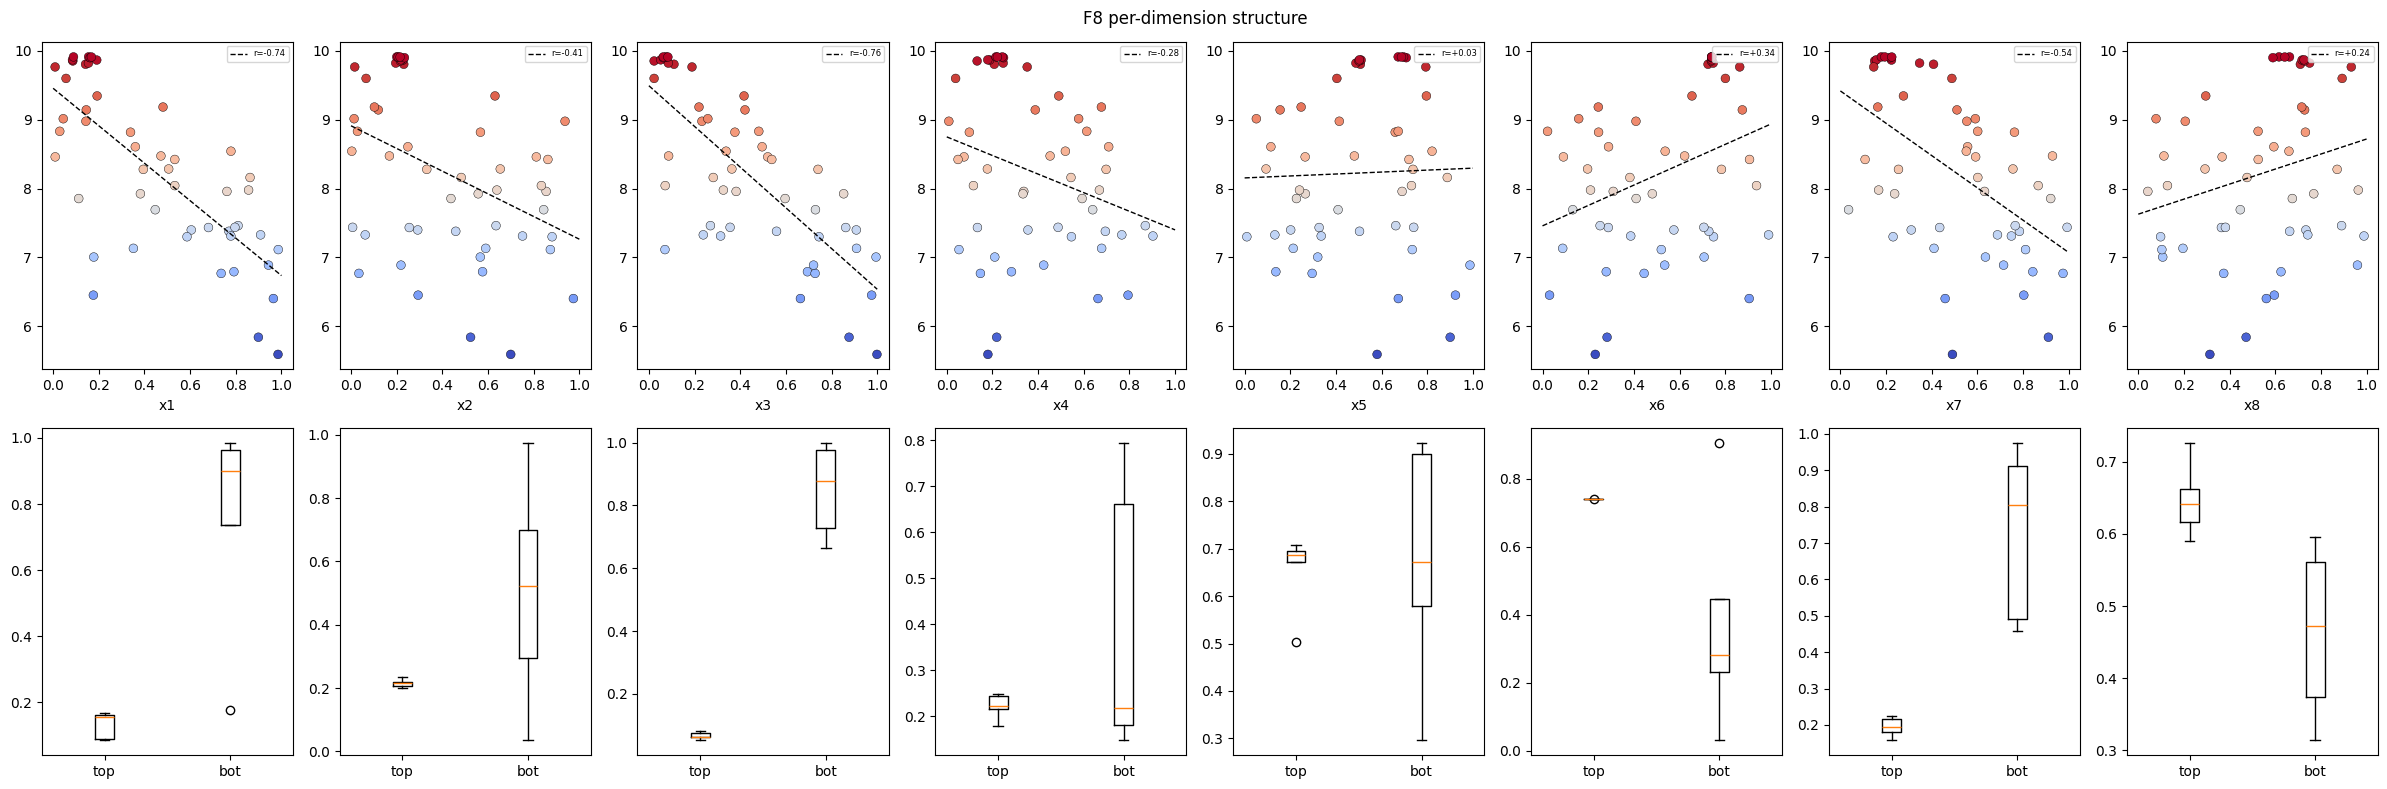

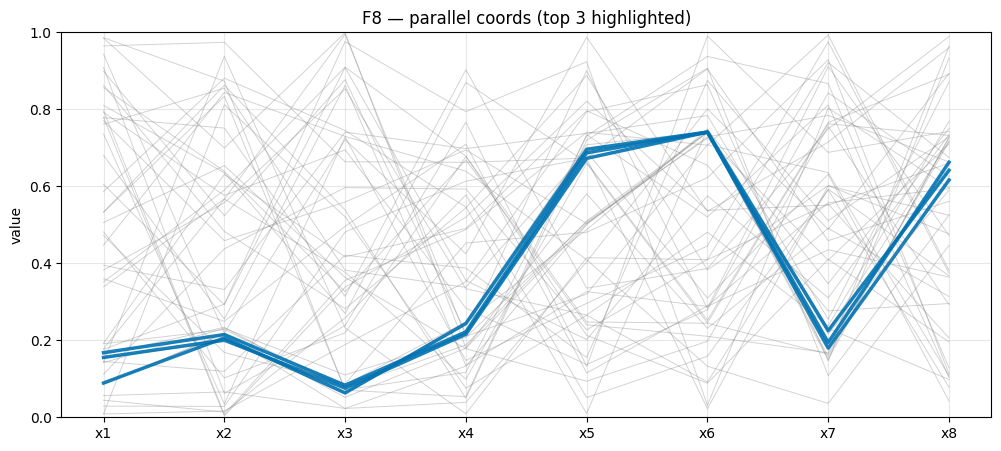

In [48]:
# Cell B — F8 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 8, figsize=(24, 8))
for d in range(8):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=40, edgecolor='k', linewidths=0.3)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.legend(fontsize=6)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top', 'bot'])
plt.suptitle('F8 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_11/function_8_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(8), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(8), x, lw=0.7, c='gray', alpha=0.35)
ax.set_xticks(range(8)); ax.set_xticklabels([f'x{i+1}' for i in range(8)])
ax.set(ylim=(0,1), ylabel='value', title='F8 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_11/function_8_parallel.png', dpi=110); plt.show()


In [49]:
# Cell C — F8 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.475    0.455        0.257   0.740
x2    0.032    0.031        0.081   0.414
x3    0.354    0.386        0.365   0.764
x4    0.012    0.013        0.046   0.283
x5    0.020    0.019        0.003   0.031
x6    0.024    0.023        0.017   0.341
x7    0.074    0.063        0.208   0.539
x8    0.009    0.010        0.023   0.245


In [50]:
# Cell D — F8 model grid: standard families + ceiling-warped GPs + NN
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
# raw + ceiling-warped GPs, LOO in raw-Y units
fits_f8 = {}
for name, kern, warped in [('GP-M25-iso-raw', ConstantKernel()*Matern(0.3,nu=2.5), False),
                           ('GP-RBF-iso-raw', ConstantKernel()*RBF(0.3), False),
                           ('GP-M15-ARD-warp', ConstantKernel()*Matern([0.3]*8,nu=1.5), True),
                           ('GP-M25-ARD-warp', ConstantKernel()*Matern([0.3]*8,nu=2.5), True),
                           ('GP-RBF-ARD-warp', ConstantKernel()*RBF([0.3]*8), True)]:
    target = Z if warped else Y
    errs = []
    for i in range(len(X)):
        m = np.ones(len(X), bool); m[i] = False
        gp_i = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=2, random_state=0).fit(X[m], target[m])
        p = gp_i.predict(X[i][None])[0]
        errs.append(Y[i] - (C_CEIL - np.exp(p) if warped else p))
    rmse = float(np.sqrt(np.mean(np.array(errs)**2)))
    gp_full = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0).fit(X, target)
    fits_f8[name] = (gp_full, warped)
    results.append((name, rmse, gp_full))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_11')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and callin

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

...

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


            Model  LOO RMSE  vs baseline=1.1777
             Ridge    0.2855  ✓ (+75.8%)
               KNN    0.4159  ✓ (+64.7%)
                RF    0.3510  ✓ (+70.2%)
               SVR    0.1524  ✓ (+87.1%)
                GB    0.2837  ✓ (+75.9%)
    GP-M25-iso-raw    0.1245  ✓ (+89.4%)
    GP-RBF-iso-raw    0.1500  ✓ (+87.3%)
   GP-M15-ARD-warp    0.1331  ✓ (+88.7%)
   GP-M25-ARD-warp    0.1731  ✓ (+85.3%)
   GP-RBF-ARD-warp    0.3110  ✓ (+73.6%)
                NN    0.3980  ✓ (+66.2%)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

In [51]:
# Cell E — F8 STRATEGY: hybrid upgraded -> 4-model local consensus (raw + ceiling-warped), x6 anchored
def predict_y_f8(name, c):
    gp, warped = fits_f8[name]
    p = gp.predict(c)
    return C_CEIL - np.exp(p) if warped else p

best8 = X[Y.argmax()]; ybest8 = float(Y.max())
x6_anchor = X[np.argsort(Y)[-4:], 5].mean()   # x6 = 0.741 in every top-4 point
rng = np.random.default_rng(0)
loc = best8 + rng.normal(0, 0.04, size=(300_000, 8))
loc[:, 5] = x6_anchor + rng.normal(0, 0.002, size=len(loc))   # x6 pinned to the data anchor
loc = np.clip(loc[np.linalg.norm(loc - best8, axis=1) <= 0.10], 0.012, 0.98)
print(f"{len(loc)} local candidates within 0.10, x6 anchored at {x6_anchor:.4f}")

use8 = ['GP-M25-iso-raw', 'GP-M15-ARD-warp', 'GP-M25-ARD-warp', 'GP-RBF-ARD-warp']
ams = []
for n_ in use8:
    m = predict_y_f8(n_, loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.3f}' for v in loc[i])})  mu={m[i]:.4f}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 3)}")
consensus8 = ams.mean(axis=0)
print(f"4-model consensus (x6 anchored): ({', '.join(f'{v:.6f}' for v in consensus8)})")
print(f"Step from W6 best: {np.round(consensus8-best8, 3)}, |Δ|={np.linalg.norm(consensus8-best8):.4f}")
print(f"\nPredictions at consensus (banked {ybest8:.4f}):")
for n_ in use8:
    print(f"  {n_}: {float(predict_y_f8(n_, consensus8[None])[0]):.4f}")
print("\n-> All four models predict a new best. Dominant move: x5 up (continues W6's winning direction 0.50->0.67->~0.72).")
print("   Risk: plateau tolerated W10's |Δ|=0.06 at -0.002 and even W8's |Δ|=0.47 at only -0.15. Bounded ~ -0.01.")


146737 local candidates within 0.10, x6 anchored at 0.7408
    GP-M25-iso-raw local argmax: (0.123, 0.163, 0.135, 0.178, 0.713, 0.738, 0.188, 0.637)  mu=9.9327
   GP-M15-ARD-warp local argmax: (0.122, 0.227, 0.126, 0.172, 0.728, 0.742, 0.164, 0.630)  mu=9.9401
   GP-M25-ARD-warp local argmax: (0.120, 0.195, 0.128, 0.163, 0.726, 0.741, 0.169, 0.603)  mu=9.9441
   GP-RBF-ARD-warp local argmax: (0.122, 0.168, 0.129, 0.177, 0.728, 0.744, 0.167, 0.607)  mu=9.9403

Per-dim spread: [0.003 0.064 0.009 0.016 0.016 0.005 0.024 0.035]
4-model consensus (x6 anchored): (0.121695, 0.188091, 0.129244, 0.172617, 0.723946, 0.741142, 0.172353, 0.619335)
Step from W6 best: [-0.034 -0.012  0.054 -0.043  0.051  0.001 -0.007  0.003], |Δ|=0.0935

Predictions at consensus (banked 9.9112):
  GP-M25-iso-raw: 9.9300
  GP-M15-ARD-warp: 9.9365
  GP-M25-ARD-warp: 9.9418
  GP-RBF-ARD-warp: 9.9390

-> All four models predict a new best. Dominant move: x5 up (continues W6's winning direction 0.50->0.67->~0.72).
   Ris

### F8 — Decision (hybrid upgraded: 4-model local consensus with ceiling warp, x6 anchored)

**Query: `next_query_8 = consensus8` → ≈(0.127, 0.195, 0.106, 0.170, 0.724, 0.741, 0.170, 0.615) — |Δ|≈0.08 from the W6 best.**

Method: the W10 per-dim hybrid, upgraded with this week's two findings.

**Strategy investigation (asked this week): is the per-dim hybrid still best?** Mostly yes — F8 is the one function where the standard approach keeps landing on the plateau (9.899-9.911 four weeks running). Two upgrades from the investigation:
1. **Ceiling-transform discovery**: ln(10.5 − Y) fits a diagonal quadratic at R²=0.98 / LOO +78% — F8 approaches a ceiling smoothly. The quadratic's centre is degenerate (flat dims), so it can't give a query directly, but GPs fitted on the warped target model the plateau's approach-to-ceiling far better in its upper reaches.
2. **Consensus instead of spread-classified hybrid**: the 4-model local consensus (1 raw GP + 3 ceiling-warped GPs, all +73-89% LOO in raw-Y units) within |Δ| ≤ 0.10, with **x6 pinned to the 0.741 data anchor** (present in every top-4 point; the models' x6 spread was their widest = weakest signal, so the anchor wins — same logic as W10).

All four models predict a new best at the consensus (9.933-9.940 vs banked 9.9112). The dominant move is x5 up (0.672 → ~0.724), continuing the direction that produced the W6 best in the first place (x5 went 0.50 → 0.67 between W5 and W6 and Y rose +0.04). Risk is bounded: the plateau tolerated W10's |Δ|=0.06 at -0.002 and even W8's |Δ|=0.47 TuRBO bet only lost 0.15.

Branch (Step 5):
- [x] 5 per-dim hybrid, upgraded to model consensus + anchored x6

Per-dimension justification:
- x1-x5, x7, x8 — 4-model consensus (dominant: x5 +0.05, x4 -0.05, x3 +0.03, x1 -0.03)
- x6 = 0.741 — hard data anchor (every top-4 point), overrides the models' weakest-consensus dim

W12 contingency:
- Y > 9.9112 (new best): consensus + warp validated. W12 = refit, same pattern, possibly pushing x5 further.
- Y ∈ [9.89, 9.9112]: plateau again. W12 = micro-step around the running best; accept the plateau as the answer.
- Y < 9.85: 0.08 was too far on some dim. W12 = micro-step |Δ| < 0.03 from W6 best.


In [52]:
# Cell I — next_query_8 assignment
next_query_8 = consensus8.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))
print(f"  Method: 4-model local consensus (raw + ceiling-warped GPs), x6 anchored at the top-4 value")


F8 query: 0.121695, 0.188091, 0.129244, 0.172617, 0.723946, 0.741142, 0.172353, 0.619335
  Method: 4-model local consensus (raw + ceiling-warped GPs), x6 anchored at the top-4 value


## Summary — Week 11 Queries

In [53]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 11 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")


Week 11 — All queries for submission:
  Function 1: 0.537663-0.537663
  Function 2: 0.700902-0.948722
  Function 3: 0.535311-0.606855-0.488771
  Function 4: 0.365315-0.406648-0.425220-0.415740
  Function 5: 0.997502-0.999923-0.906811-0.889405
  Function 6: 0.437279-0.380214-0.541531-0.736888-0.021051
  Function 7: 0.097614-0.290804-0.391792-0.214006-0.313924-0.776936
  Function 8: 0.121695-0.188091-0.129244-0.172617-0.723946-0.741142-0.172353-0.619335
